# Business Process Anomaly Detection — Traffic Fines
### Pipeline: Preprocessing → Digital Twin → DDC → MV-ARM → Intelligent Body
---
**Dataset:** Traffic Fines Event Log (460.000+ events, 129.000+ cases)  
**Metode:** Digital Twin + Dynamic Declarative Constraints (DDC) + Multi-View Association Rule Mining (MV-ARM)  
**Evaluasi:** ROC Curve + Youden's J Statistic (menggunakan **real label**: `deviant` / `regular`)  

---
** Regular **
- Send
- Notification
- Penalty
- Payment

** Deviant **
- terlalu lama
- tidak ada payment
- urutan aneh
- terlalu banyak penalty
- proses berhenti di tengah

## 📦 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             classification_report, confusion_matrix,
                             accuracy_score, matthews_corrcoef)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import defaultdict
import itertools

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = Path('dataOutput')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Output directory: {OUTPUT_DIR.resolve()}")

# Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})
print("✅ Libraries loaded successfully")

📁 Output directory: /Users/mac/Documents/Deinony/Project/Aritificial Intelligence/DeteksiAnomaliBisnis/sendSample/dataOutput
✅ Libraries loaded successfully


## 📂 2. Load & Preview Data

In [2]:
# Load dataset — separator semicolon
df_raw = pd.read_csv('data/traffic_fines_1.csv', sep=';', low_memory=False)

# Rename kolom agar konsisten (hapus spasi)
df_raw = df_raw.rename(columns={
    'Case ID'           : 'case_id',
    'Activity'          : 'activity_name',
    'Complete Timestamp': 'timestamp',
    'Resource'          : 'resource',
})

print(f"📊 Shape          : {df_raw.shape}")
print(f"📋 Columns        : {df_raw.columns.tolist()}")
print(f"🔑 Unique cases   : {df_raw['case_id'].nunique():,}")
print(f"⚡ Activities     : {df_raw['activity_name'].unique().tolist()}")
print(f"🏷️  Label values   : {df_raw['label'].value_counts().to_dict()}")
print()
df_raw.head(8)

📊 Shape          : (460556, 21)
📋 Columns        : ['article', 'vehicleClass', 'amount', 'points', 'case_id', 'activity_name', 'resource', 'lastSent', 'notificationType', 'dismissal', 'expense', 'timestamp', 'timesincemidnight', 'month', 'weekday', 'hour', 'timesincelastevent', 'timesincecasestart', 'event_nr', 'open_cases', 'label']
🔑 Unique cases   : 129,615
⚡ Activities     : ['Create Fine', 'Send Fine', 'Insert Fine Notification', 'Add penalty', 'Payment', 'Insert Date Appeal to Prefecture', 'Send Appeal to Prefecture', 'Receive Result Appeal from Prefecture', 'Notify Result Appeal to Offender', 'Appeal to Judge']
🏷️  Label values   : {'deviant': 239478, 'regular': 221078}



,article,vehicleClass,amount,points,case_id,activity_name,resource,lastSent,notificationType,dismissal,...,timestamp,timesincemidnight,month,weekday,hour,timesincelastevent,timesincecasestart,event_nr,open_cases,label
0,157.0,A,35.0,0.0,A100,Create Fine,561.0,missing,missing,NIL,...,2006-08-02 01:00:00,60,8,2,1,0.0,0.0,1,11246,deviant
1,157.0,A,35.0,0.0,A100,Send Fine,561.0,missing,missing,NIL,...,2006-12-12 01:00:00,60,12,1,1,190080.0,190080.0,2,12380,deviant
2,157.0,A,35.0,0.0,A100,Insert Fine Notification,561.0,P,P,NIL,...,2007-01-15 01:00:00,60,1,0,1,48960.0,239040.0,3,12202,deviant
3,157.0,A,71.5,0.0,A100,Add penalty,561.0,P,P,NIL,...,2007-03-16 01:00:00,60,3,4,1,86400.0,325440.0,4,7749,deviant
4,157.0,A,36.0,0.0,A10000,Create Fine,561.0,missing,missing,NIL,...,2007-03-09 01:00:00,60,3,4,1,0.0,0.0,1,7756,regular
5,157.0,A,36.0,0.0,A10000,Send Fine,561.0,missing,missing,NIL,...,2007-07-17 01:00:00,60,7,1,1,187200.0,187200.0,2,9347,regular
6,157.0,A,36.0,0.0,A10000,Insert Fine Notification,561.0,P,P,NIL,...,2007-08-02 01:00:00,60,8,3,1,23040.0,210240.0,3,9838,regular
7,157.0,A,74.0,0.0,A10000,Add penalty,561.0,P,P,NIL,...,2007-10-01 01:00:00,60,10,0,1,86400.0,296640.0,4,10875,regular


## 🔎 3. Exploratory Data Analysis (EDA)

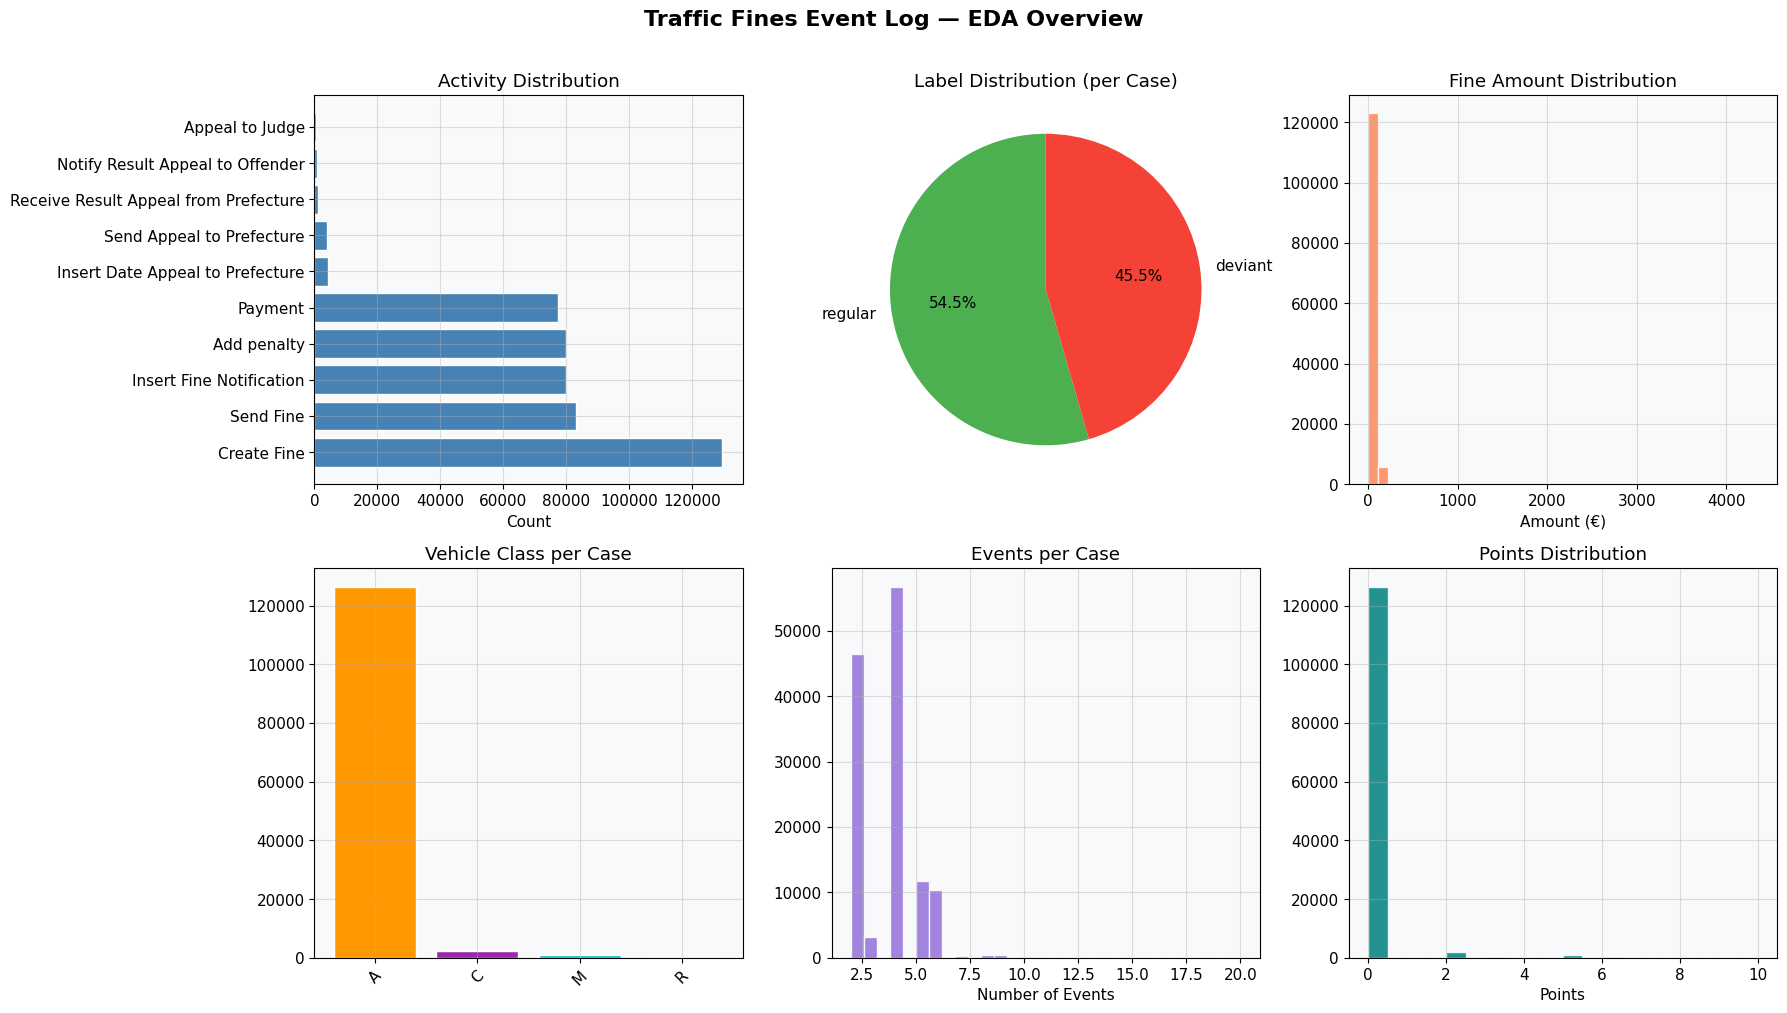

✅ EDA complete


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Traffic Fines Event Log — EDA Overview', fontsize=16, fontweight='bold', y=1.01)

# (a) Activity distribution
activity_counts = df_raw['activity_name'].value_counts()
axes[0,0].barh(activity_counts.index, activity_counts.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Activity Distribution')
axes[0,0].set_xlabel('Count')

# (b) Label distribution
label_counts = df_raw.drop_duplicates('case_id')['label'].value_counts()
axes[0,1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
              colors=['#4CAF50','#F44336'], startangle=90)
axes[0,1].set_title('Label Distribution (per Case)')

# (c) Amount histogram
axes[0,2].hist(df_raw.drop_duplicates('case_id')['amount'].dropna(), bins=40,
               color='coral', edgecolor='white', alpha=0.8)
axes[0,2].set_title('Fine Amount Distribution')
axes[0,2].set_xlabel('Amount (€)')

# (d) Vehicle class
vc = df_raw.drop_duplicates('case_id')['vehicleClass'].value_counts().head(10)
axes[1,0].bar(vc.index, vc.values, color=['#FF9800','#9C27B0','#00BCD4','#E53935','#43A047',
                                            '#1E88E5','#FB8C00','#8E24AA','#00ACC1','#E53935'],
              edgecolor='white')
axes[1,0].set_title('Vehicle Class per Case')
axes[1,0].tick_params(axis='x', rotation=45)

# (e) Events per case
events_per_case = df_raw.groupby('case_id').size()
axes[1,1].hist(events_per_case, bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1,1].set_title('Events per Case')
axes[1,1].set_xlabel('Number of Events')

# (f) Points distribution
axes[1,2].hist(df_raw.drop_duplicates('case_id')['points'].dropna(), bins=20,
               color='teal', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Points Distribution')
axes[1,2].set_xlabel('Points')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_01_eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA complete")

## 🧹 4. Data Preprocessing (Fase 1 Flowchart)
> **Pipeline:** Event Log → Timestamp Parsing & Case Ordering → Feature Extraction → Normalization (Z-Score)

In [4]:
# ── Step 1: Timestamp parsing & case ordering ──────────────────────────────
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

# ── Step 2: Build case-level features ────────────────────────────────────────
# Urutan logis proses traffic fine
ACTIVITY_ORDER = [
    'Create Fine',
    'Send Fine',
    'Insert Fine Notification',
    'Add penalty',
    'Payment',
    'Insert Date Appeal to Prefecture',
    'Send Appeal to Prefecture',
    'Receive Result Appeal from Prefecture',
    'Notify Result Appeal to Offender',
    'Appeal to Judge',
]
activity_rank = {a: i for i, a in enumerate(ACTIVITY_ORDER)}

def extract_case_features(grp):
    grp = grp.sort_values('timestamp')
    activities = grp['activity_name'].tolist()
    timestamps = grp['timestamp'].tolist()
    n = len(activities)

    # ── CONTROL FLOW features ──
    expected_seq = [activity_rank.get(a, -1) for a in activities]
    seq_violations = sum(
        1 for i in range(1, len(expected_seq))
        if expected_seq[i] != -1 and expected_seq[i-1] != -1 and expected_seq[i] < expected_seq[i-1]
    )
    missing_steps = len({'Create Fine', 'Send Fine'} - set(activities))  # minimum required steps
    duplicate_steps = n - len(set(activities))
    has_payment  = int('Payment' in activities)
    has_appeal   = int(any('Appeal' in a for a in activities))
    has_penalty  = int('Add penalty' in activities)

    # ── TEMPORAL features ──
    valid_ts = [t for t in timestamps if pd.notna(t)]
    if len(valid_ts) > 1:
        durations = [(valid_ts[i+1] - valid_ts[i]).total_seconds() / 3600
                     for i in range(len(valid_ts)-1)]
        total_duration_hrs = (valid_ts[-1] - valid_ts[0]).total_seconds() / 3600
        mean_step_dur = np.mean(durations)
        std_step_dur  = np.std(durations) if len(durations) > 1 else 0
        max_step_dur  = np.max(durations)
    else:
        durations, total_duration_hrs = [0], 0
        mean_step_dur = std_step_dur = max_step_dur = 0

    # ── RESOURCE features ──
    resources   = grp['resource'].dropna().nunique()
    rpa_flag    = int((grp['resource'] == '0').any() or (grp['resource'] == 0).any())

    # ── CASE attributes ──
    amount   = pd.to_numeric(grp['amount'].iloc[0],  errors='coerce')
    points   = pd.to_numeric(grp['points'].iloc[0],  errors='coerce')
    expense  = pd.to_numeric(grp['expense'].dropna().sum(), errors='coerce')

    return pd.Series({
        # Control flow
        'cf_seq_violations' : seq_violations,
        'cf_missing_steps'  : missing_steps,
        'cf_duplicate_steps': duplicate_steps,
        'cf_n_events'       : n,
        'cf_has_payment'    : has_payment,
        'cf_has_appeal'     : has_appeal,
        'cf_has_penalty'    : has_penalty,
        # Temporal
        'temp_total_hrs'    : total_duration_hrs,
        'temp_mean_step_hrs': mean_step_dur,
        'temp_std_step_hrs' : std_step_dur,
        'temp_max_step_hrs' : max_step_dur,
        # Resource
        'res_n_resources'   : resources,
        'res_rpa_flag'      : rpa_flag,
        # Attributes
        'amount'            : amount if pd.notna(amount) else 0,
        'points'            : points  if pd.notna(points)  else 0,
        'expense'           : expense if pd.notna(expense) else 0,
        # Meta
        'vehicleClass'      : grp['vehicleClass'].iloc[0],
        'dismissal'         : grp['dismissal'].iloc[0],
        'label'             : grp['label'].iloc[0],
    })

print("⏳ Extracting case features (~129,000 cases) — harap tunggu...")
case_features = df.groupby('case_id').apply(extract_case_features).reset_index()
print(f"✅ Case features extracted: {case_features.shape}")

# ── Step 3: Z-score normalization ────────────────────────────────────────────
NUMERIC_COLS = [
    'cf_seq_violations','cf_missing_steps','cf_duplicate_steps','cf_n_events',
    'cf_has_payment','cf_has_appeal','cf_has_penalty',
    'temp_total_hrs','temp_mean_step_hrs','temp_std_step_hrs','temp_max_step_hrs',
    'res_n_resources','res_rpa_flag',
    'amount','points','expense'
]

scaler = StandardScaler()
case_features_scaled = case_features.copy()
case_features_scaled[NUMERIC_COLS] = scaler.fit_transform(case_features[NUMERIC_COLS].fillna(0))

print("\n📋 Feature summary (raw):")
case_features[NUMERIC_COLS].describe().round(2)

⏳ Extracting case features (~129,000 cases) — harap tunggu...
✅ Case features extracted: (129615, 20)

📋 Feature summary (raw):


,cf_seq_violations,cf_missing_steps,cf_duplicate_steps,cf_n_events,cf_has_payment,cf_has_appeal,cf_has_penalty,temp_total_hrs,temp_mean_step_hrs,temp_std_step_hrs,temp_max_step_hrs,res_n_resources,res_rpa_flag,amount,points,expense
count,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.00,129615.0,129615.00,129615.00,129615.00
mean,0.07,0.36,0.06,3.55,0.54,0.04,0.62,3395.75,1032.62,684.85,2034.28,1.00,0.0,44.86,0.08,26.35
std,0.26,0.48,0.27,1.37,0.50,0.18,0.49,4281.90,1015.82,1300.55,3323.93,0.07,0.0,50.05,0.59,26.11
min,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.0,0.00,0.00,0.00
25%,0.00,0.00,0.00,2.00,0.00,0.00,0.00,168.00,168.00,0.00,168.00,1.00,0.0,32.80,0.00,0.00
50%,0.00,0.00,0.00,4.00,1.00,0.00,1.00,3168.00,1032.00,485.70,1440.00,1.00,0.0,35.00,0.00,30.00
75%,0.00,1.00,0.00,4.00,1.00,0.00,1.00,4632.00,1448.00,918.49,2640.00,1.00,0.0,38.00,0.00,42.75
max,3.00,1.00,14.00,20.00,1.00,1.00,1.00,104928.00,23088.00,40227.73,101304.00,2.00,0.0,4351.00,10.00,360.00


## ✂️ 5. Time-Based Train/Test Split 70:30 (Fase 2)

In [5]:
# Get first timestamp per case
case_start_time = df.groupby('case_id')['timestamp'].min().reset_index()
case_start_time.columns = ['case_id', 'start_time']
case_features = case_features.merge(case_start_time, on='case_id')

# Sort by case start time and split 70:30
case_features = case_features.sort_values('start_time').reset_index(drop=True)
split_idx = int(len(case_features) * 0.7)

train_df = case_features.iloc[:split_idx].copy()
test_df  = case_features.iloc[split_idx:].copy()

print(f"📅 Train set: {len(train_df):,} cases  "
      f"({train_df['start_time'].min().date()} → {train_df['start_time'].max().date()})")
print(f"📅 Test set : {len(test_df):,} cases  "
      f"({test_df['start_time'].min().date()} → {test_df['start_time'].max().date()})")
print(f"\n✅ Split ratio: {len(train_df)/len(case_features):.1%} / {len(test_df)/len(case_features):.1%}")
print(f"\n🏷️  Label distribusi test set:")
print(test_df['label'].value_counts())

📅 Train set: 90,730 cases  (2000-01-01 → 2008-05-22)
📅 Test set : 38,885 cases  (2008-05-22 → 2013-06-18)

✅ Split ratio: 70.0% / 30.0%

🏷️  Label distribusi test set:
label
regular    22844
deviant    16041
Name: count, dtype: int64


## 🤖 6. Build Digital Twin & Statistical Baseline (Fase 2)
> Digital Twin di-fit pada **kasus normal** (label=`regular`) dari training set.

ℹ️  Fitting Digital Twin pada 47,758 kasus normal (regular)...
✅ Digital Twin fitted on 47,758 cases, 16 features


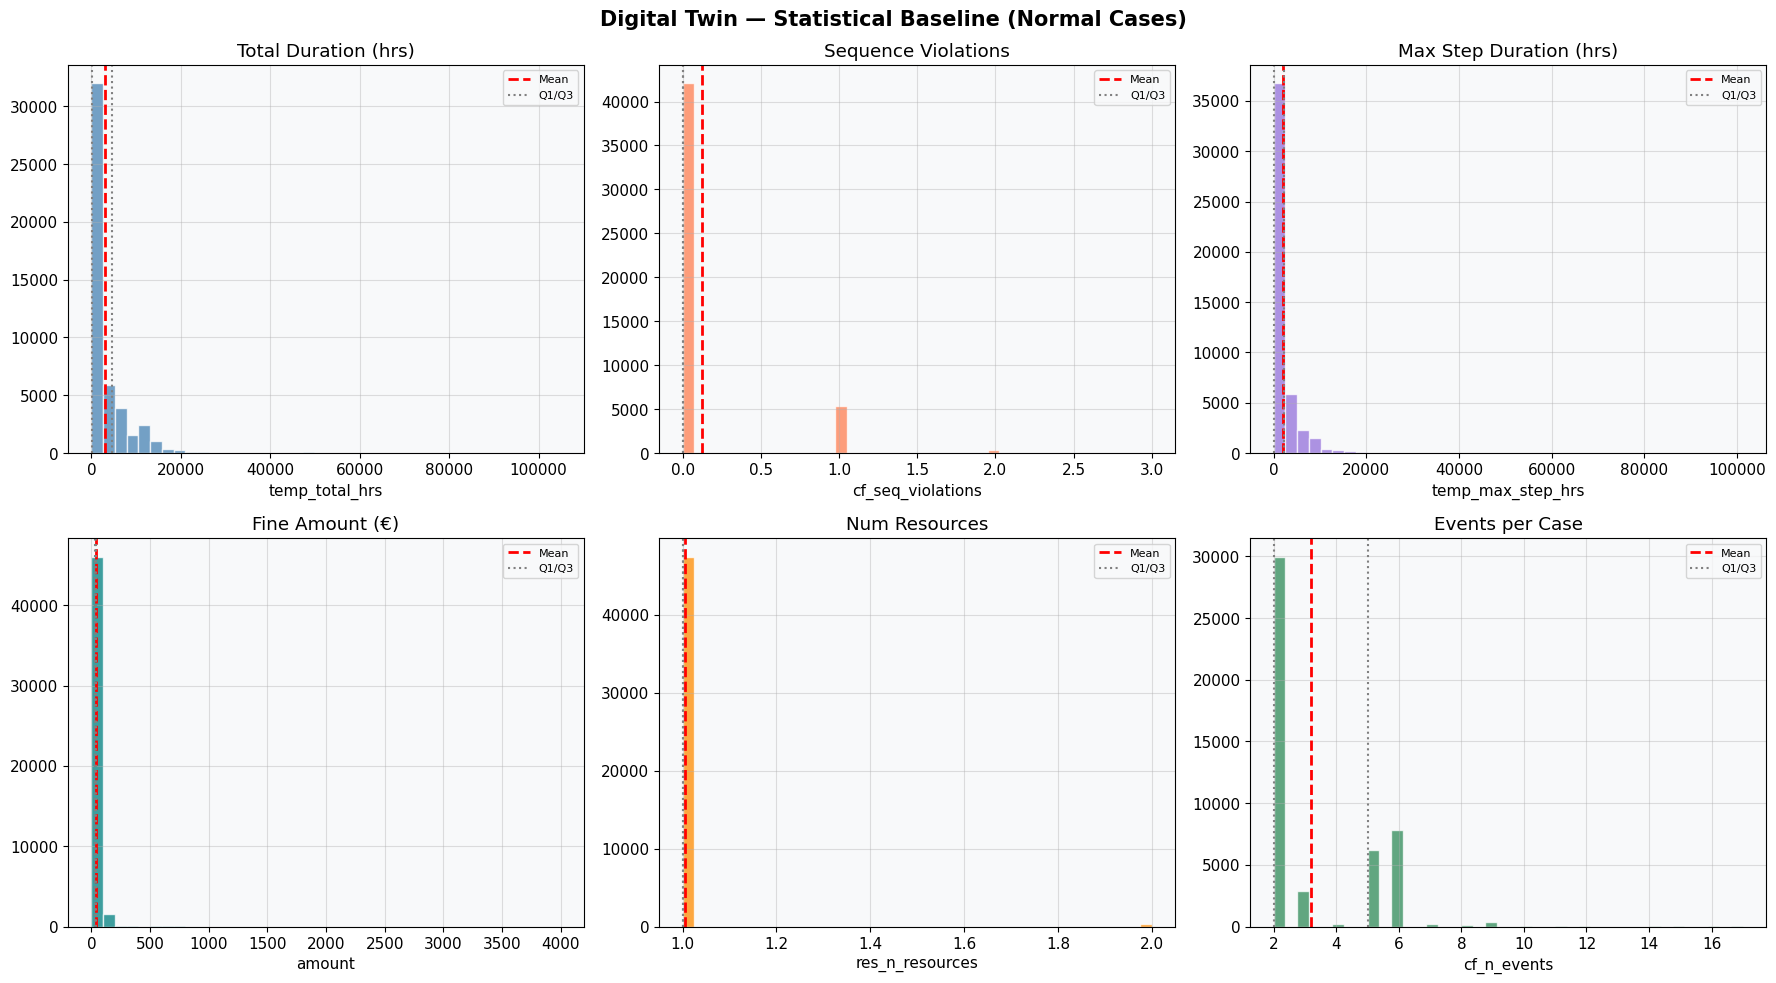

In [6]:
class DigitalTwin:
    """
    Digital Twin: model statistik dari proses bisnis normal.
    Menyimpan mean, std, dan percentile untuk setiap fitur.
    """
    def __init__(self):
        self.baseline = {}
        self.percentiles = {}

    def fit(self, df, numeric_cols):
        for col in numeric_cols:
            vals = df[col].dropna()
            self.baseline[col] = {
                'mean'  : vals.mean(),
                'std'   : vals.std(),
                'median': vals.median(),
                'q1'    : vals.quantile(0.25),
                'q3'    : vals.quantile(0.75),
                'iqr'   : vals.quantile(0.75) - vals.quantile(0.25),
            }
            self.percentiles[col] = np.percentile(vals, np.arange(0, 101, 5))
        print(f"✅ Digital Twin fitted on {len(df):,} cases, {len(numeric_cols)} features")

    def get_z_score(self, row, col):
        b = self.baseline[col]
        if b['std'] == 0:
            return 0.0
        return abs((row[col] - b['mean']) / b['std'])

    def get_iqr_score(self, row, col):
        b = self.baseline[col]
        if b['iqr'] == 0:
            return 0.0
        return max(0, (row[col] - b['q3']) / b['iqr'],
                      (b['q1'] - row[col]) / b['iqr'])

# Fit Digital Twin HANYA pada kasus normal (regular) di training set
train_normal = train_df[train_df['label'] == 'regular'].copy()
print(f"ℹ️  Fitting Digital Twin pada {len(train_normal):,} kasus normal (regular)...")

dt = DigitalTwin()
dt.fit(train_normal, NUMERIC_COLS)

# Visualize baseline
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Digital Twin — Statistical Baseline (Normal Cases)', fontsize=15, fontweight='bold')

key_features = [
    ('temp_total_hrs',     'Total Duration (hrs)',  'steelblue'),
    ('cf_seq_violations',  'Sequence Violations',   'coral'),
    ('temp_max_step_hrs',  'Max Step Duration (hrs)','mediumpurple'),
    ('amount',             'Fine Amount (€)',        'teal'),
    ('res_n_resources',    'Num Resources',          'darkorange'),
    ('cf_n_events',        'Events per Case',        'seagreen'),
]

for ax, (col, label, color) in zip(axes.flat, key_features):
    vals = train_normal[col]
    ax.hist(vals, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(dt.baseline[col]['mean'], color='red',  linestyle='--', lw=2, label='Mean')
    ax.axvline(dt.baseline[col]['q1'],   color='gray', linestyle=':',  lw=1.5, label='Q1/Q3')
    ax.axvline(dt.baseline[col]['q3'],   color='gray', linestyle=':',  lw=1.5)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_02_digital_twin_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

## ⚖️ 7. Dynamic Declarative Constraints (DDC) (Fase 2 & 3)
> DDC mendefinisikan **batas toleransi adaptif** berdasarkan distribusi kasus normal.

In [7]:
class DynamicDeclarativeConstraints:
    """
    DDC: Aturan batas dinamis yang beradaptasi dengan distribusi data.
    """
    def __init__(self, z_threshold=2.5, iqr_multiplier=2.0):
        self.z_threshold    = z_threshold
        self.iqr_multiplier = iqr_multiplier
        self.constraints    = {}

    def fit(self, digital_twin, numeric_cols):
        for col in numeric_cols:
            b = digital_twin.baseline[col]
            self.constraints[col] = {
                'upper_z'  : b['mean'] + self.z_threshold * b['std'],
                'lower_z'  : b['mean'] - self.z_threshold * b['std'],
                'upper_iqr': b['q3']   + self.iqr_multiplier * b['iqr'],
                'lower_iqr': b['q1']   - self.iqr_multiplier * b['iqr'],
            }
        # Hard business rules untuk traffic fines
        self.hard_rules = {
            'cf_seq_violations' : (0, 2),    # max 2 sequence violations
            'cf_missing_steps'  : (0, 0),    # Create Fine & Send Fine wajib ada
            'cf_duplicate_steps': (0, 3),    # max 3 duplikat
            'res_n_resources'   : (1, 5),    # 1 sampai 5 resource
        }
        print(f"✅ DDC initialized with {len(self.constraints)} constraints + {len(self.hard_rules)} hard rules")

    def evaluate(self, row):
        violations = []
        scores     = {}
        for col, c in self.constraints.items():
            val = row[col]
            z = abs((val - (c['upper_z'] + c['lower_z']) / 2) /
                    max(1e-9, (c['upper_z'] - c['lower_z']) / (2 * self.z_threshold)))
            scores[f'{col}_z'] = z
            if val > c['upper_z'] or val < c['lower_z']:
                violations.append(f'DDC_Z:{col}')
            if val > c['upper_iqr'] or val < c['lower_iqr']:
                violations.append(f'DDC_IQR:{col}')

        for col, (lo, hi) in self.hard_rules.items():
            if col in row.index and (row[col] < lo or row[col] > hi):
                violations.append(f'DDC_HARD:{col}={row[col]:.0f}')

        return violations, scores

# Fit DDC
ddc = DynamicDeclarativeConstraints(z_threshold=2.5, iqr_multiplier=2.0)
ddc.fit(dt, NUMERIC_COLS)

# Sample evaluation
sample = test_df.iloc[0]
viols, scores = ddc.evaluate(sample)
print(f"\nSample case DDC evaluation (label={sample['label']}):")
print(f"  Violations : {viols if viols else 'None'}")
print(f"  Z-scores (top 5): {dict(list(sorted(scores.items(), key=lambda x: -x[1]))[:5])}")

✅ DDC initialized with 16 constraints + 4 hard rules

Sample case DDC evaluation (label=regular):
  Violations : ['DDC_IQR:amount', 'DDC_HARD:cf_missing_steps=1']
  Z-scores (top 5): {'cf_missing_steps_z': np.float64(0.7702953586130648), 'cf_n_events_z': np.float64(0.6920852487064676), 'cf_has_penalty_z': np.float64(0.666732779428647), 'expense_z': np.float64(0.637616868114816), 'amount_z': np.float64(0.5072588826869165)}


## 📐 8. Multi-View Association Rule Mining (MV-ARM) (Fase 2)
> MV-ARM menambang pola kombinasi anomali dari tiga dimensi: **Control Flow**, **Temporal**, **Resource**

In [8]:
class MVARMiner:
    """
    Multi-View Association Rule Mining.
    """
    def __init__(self, min_support=0.05, min_confidence=0.6, min_lift=1.2):
        self.min_support    = min_support
        self.min_confidence = min_confidence
        self.min_lift       = min_lift
        self.rules          = {'cf': None, 'temporal': None, 'resource': None}

    def _discretize(self, df):
        """Binarize fitur untuk Apriori."""
        items = pd.DataFrame(index=df.index)
        # Control flow view
        items['CF_seq_violation']  = df['cf_seq_violations']  > 0
        items['CF_missing_step']   = df['cf_missing_steps']   > 0
        items['CF_duplicate']      = df['cf_duplicate_steps'] > 0
        items['CF_has_appeal']     = df['cf_has_appeal']      == 1
        items['CF_has_penalty']    = df['cf_has_penalty']     == 1
        items['CF_no_payment']     = df['cf_has_payment']     == 0
        items['CF_too_many_events']= df['cf_n_events']        > df['cf_n_events'].quantile(0.90)
        # Temporal view
        med_hrs = df['temp_total_hrs'].median()
        std_hrs = df['temp_total_hrs'].std()
        items['TEMP_very_fast']    = df['temp_total_hrs'] < (med_hrs - std_hrs)
        items['TEMP_very_slow']    = df['temp_total_hrs'] > (med_hrs + std_hrs)
        items['TEMP_high_variance']= df['temp_std_step_hrs'] > df['temp_std_step_hrs'].quantile(0.75)
        items['TEMP_long_max_step']= df['temp_max_step_hrs'] > df['temp_max_step_hrs'].quantile(0.90)
        # Resource view
        items['RES_multi_resource']= df['res_n_resources'] > 1
        items['RES_rpa_involved']  = df['res_rpa_flag']    == 1
        items['RES_high_expense']  = df['expense']         > df['expense'].quantile(0.90)
        items['RES_high_amount']   = df['amount']          > df['amount'].quantile(0.90)
        return items

    def fit(self, train_df):
        items = self._discretize(train_df)
        for view, cols in [
            ('cf',       [c for c in items.columns if c.startswith('CF_')]),
            ('temporal', [c for c in items.columns if c.startswith('TEMP_')]),
            ('resource', [c for c in items.columns if c.startswith('RES_')]),
        ]:
            sub = items[cols].astype(bool)
            try:
                freq = apriori(sub, min_support=self.min_support, use_colnames=True)
                if len(freq) > 0:
                    rules = association_rules(freq, metric='confidence',
                                             min_threshold=self.min_confidence)
                    rules = rules[rules['lift'] >= self.min_lift].copy()
                    self.rules[view] = rules
                    print(f"  [{view:8s}] {len(freq):3d} frequent itemsets, {len(rules):3d} rules mined")
                else:
                    print(f"  [{view:8s}] No frequent itemsets found")
            except Exception as e:
                print(f"  [{view:8s}] Error: {e}")
        self._items_func = self._discretize
        return self

    def check_case(self, row_df):
        items = self._items_func(row_df)
        triggered = []
        for view, rules in self.rules.items():
            if rules is None or len(rules) == 0:
                continue
            for _, rule in rules.iterrows():
                antecedent = set(rule['antecedents'])
                if all(items.get(a, pd.Series([False])).values[0] for a in antecedent):
                    triggered.append({
                        'view'      : view,
                        'rule'      : f"{set(rule['antecedents'])} => {set(rule['consequents'])}",
                        'confidence': round(rule['confidence'], 3),
                        'lift'      : round(rule['lift'], 3),
                        'support'   : round(rule['support'], 3),
                    })
        return triggered

print("⏳ Mining MV-ARM rules on training data...")
mva = MVARMiner(min_support=0.05, min_confidence=0.6, min_lift=1.2)
mva.fit(train_df)

for view in ['cf', 'temporal', 'resource']:
    if mva.rules[view] is not None and len(mva.rules[view]) > 0:
        print(f"\n🔍 Top rules — {view.upper()} view:")
        top = mva.rules[view].sort_values('lift', ascending=False).head(3)
        for _, r in top.iterrows():
            print(f"   {set(r['antecedents'])} → {set(r['consequents'])}  "
                  f"[conf={r['confidence']:.2f}, lift={r['lift']:.2f}, sup={r['support']:.3f}]")

⏳ Mining MV-ARM rules on training data...
  [cf      ]  14 frequent itemsets,  19 rules mined
  [temporal]   7 frequent itemsets,   9 rules mined
  [resource]   2 frequent itemsets,   0 rules mined

🔍 Top rules — CF view:
   {'CF_too_many_events'} → {'CF_has_penalty', 'CF_duplicate'}  [conf=0.70, lift=10.37, sup=0.068]
   {'CF_has_penalty', 'CF_duplicate'} → {'CF_too_many_events'}  [conf=1.00, lift=10.37, sup=0.068]
   {'CF_duplicate'} → {'CF_has_penalty', 'CF_too_many_events'}  [conf=0.99, lift=10.22, sup=0.068]

🔍 Top rules — TEMPORAL view:
   {'TEMP_very_slow', 'TEMP_high_variance'} → {'TEMP_long_max_step'}  [conf=0.96, lift=9.70, sup=0.067]
   {'TEMP_long_max_step'} → {'TEMP_very_slow', 'TEMP_high_variance'}  [conf=0.67, lift=9.70, sup=0.067]
   {'TEMP_long_max_step', 'TEMP_high_variance'} → {'TEMP_very_slow'}  [conf=0.68, lift=9.48, sup=0.067]


## 🧠 9. Intelligent Body — Anomaly Scoring & Risk Classification (Fase 4)
Link Referensi Risk Level (paper): ...
> Menggabungkan DDC + MV-ARM + Z-score menjadi **composite anomaly score**.  
> Risk level: Low (< 0.3) | Medium (0.3–0.6) | High (> 0.6)

In [9]:
class IntelligentBody:
    """
    Intelligent Body: mengintegrasi semua sinyal anomali menjadi
    composite score, risk level, dan penjelasan.
    """
    WEIGHTS = {
        'ddc_violation' : 0.30,
        'z_score'       : 0.35,
        'mv_arm'        : 0.20,
        'business_rule' : 0.15,
    }

    def __init__(self, digital_twin, ddc, mv_arm_miner):
        self.dt  = digital_twin
        self.ddc = ddc
        self.mva = mv_arm_miner

    def score_case(self, row):
        # ── 1. DDC evaluation ────────────────────────────────────────────────
        ddc_viols, z_scores = self.ddc.evaluate(row)
        ddc_score = min(1.0, len(ddc_viols) / 6.0)

        # ── 2. Z-score composite ─────────────────────────────────────────────
        key_z_features = [
            'cf_seq_violations', 'temp_total_hrs', 'temp_max_step_hrs',
            'amount', 'res_n_resources'
        ]
        z_vals      = [self.dt.get_z_score(row, c) for c in key_z_features]
        z_composite = min(1.0, np.mean(z_vals) / 3.0)

        # ── 3. MV-ARM check ──────────────────────────────────────────────────
        row_df    = pd.DataFrame([row])
        triggered = self.mva.check_case(row_df)
        arm_score = min(1.0, len(triggered) / 5.0)

        # ── 4. Business rules untuk traffic fines ─────────────────────────────
        br_score = 0.0
        if row['cf_seq_violations'] > 1:  br_score += 0.3
        if row['cf_missing_steps']  > 0:  br_score += 0.4   # Create Fine wajib ada
        if row['cf_has_appeal'] == 1 and row['cf_has_payment'] == 0:
            br_score += 0.2                                  # appeal tanpa bayar
        if row['temp_total_hrs'] < 1:     br_score += 0.3   # proses terlalu cepat
        br_score = min(1.0, br_score)

        # ── 5. Composite score ────────────────────────────────────────────────
        W = self.WEIGHTS
        composite = (
            W['ddc_violation'] * ddc_score   +
            W['z_score']       * z_composite +
            W['mv_arm']        * arm_score   +
            W['business_rule'] * br_score
        )

        # ── 6. Risk level ─────────────────────────────────────────────────────
        if composite >= 0.6:   risk = 'High'
        elif composite >= 0.3: risk = 'Medium'
        else:                  risk = 'Low'

        # ── 7. Anomaly type ───────────────────────────────────────────────────
        anomaly_types = []
        if row['cf_seq_violations'] > 0 or row['cf_missing_steps'] > 0:
            anomaly_types.append('Control-Flow')
        if z_vals[1] > 2.5 or z_vals[2] > 2.5:
            anomaly_types.append('Temporal')
        if row['res_n_resources'] > 3:
            anomaly_types.append('Resource')
        if not anomaly_types:
            anomaly_types.append('None')

        return {
            'anomaly_score' : round(composite, 4),
            'risk_level'    : risk,
            'anomaly_types' : '|'.join(anomaly_types),
            'ddc_score'     : round(ddc_score, 4),
            'z_score'       : round(z_composite, 4),
            'arm_score'     : round(arm_score, 4),
            'br_score'      : round(br_score, 4),
            'ddc_violations': len(ddc_viols),
            'arm_rules_hit' : len(triggered),
            'explanation'   : self._explain(ddc_viols, triggered, anomaly_types, z_vals, key_z_features)
        }

    def _explain(self, ddc_viols, triggered, atypes, z_vals, feat_names):
        parts = []
        if ddc_viols:
            parts.append(f"DDC violations: {'; '.join(ddc_viols[:3])}")
        top_z = sorted(zip(feat_names, z_vals), key=lambda x: -x[1])[:2]
        if top_z[0][1] > 2:
            parts.append(f"High z-score: {top_z[0][0]} (z={top_z[0][1]:.2f})")
        if triggered:
            parts.append(f"MV-ARM rule triggered: {triggered[0]['view']} view")
        return ' | '.join(parts) if parts else 'No significant deviations detected'

    def score_all(self, df):
        results = []
        for _, row in df.iterrows():
            r = self.score_case(row)
            r['case_id'] = row['case_id']
            results.append(r)
        return pd.DataFrame(results)

# Instantiate
ib = IntelligentBody(dt, ddc, mva)

print("⏳ Scoring test cases...")
results_df = ib.score_all(test_df)
print(f"✅ Scored {len(results_df):,} cases")
print("\n📊 Risk level distribution:")
print(results_df['risk_level'].value_counts())
print("\n📊 Anomaly type distribution:")
all_types = results_df['anomaly_types'].str.split('|').explode()
print(all_types.value_counts())

⏳ Scoring test cases...
✅ Scored 38,885 cases

📊 Risk level distribution:
risk_level
Low       33504
Medium     4162
High       1219
Name: count, dtype: int64

📊 Anomaly type distribution:
anomaly_types
None            20504
Control-Flow    17888
Temporal          646
Name: count, dtype: int64


In [10]:
all_types

0        Control-Flow
1        Control-Flow
2                None
3                None
4        Control-Flow
             ...     
38880    Control-Flow
38881    Control-Flow
38882    Control-Flow
38883    Control-Flow
38884    Control-Flow
Name: anomaly_types, Length: 39038, dtype: object

## 📈 10. ROC Curve & Youden's J Statistic — Optimal Threshold
> Dataset ini memiliki **real label** (`deviant` / `regular`), sehingga evaluasi menggunakan ground truth asli — tidak perlu pseudo-label.  
> **Youden's J** = Sensitivity + Specificity − 1 → threshold optimal.

📌 Real anomaly rate (deviant): 41.3%  (16,041 / 38,885)


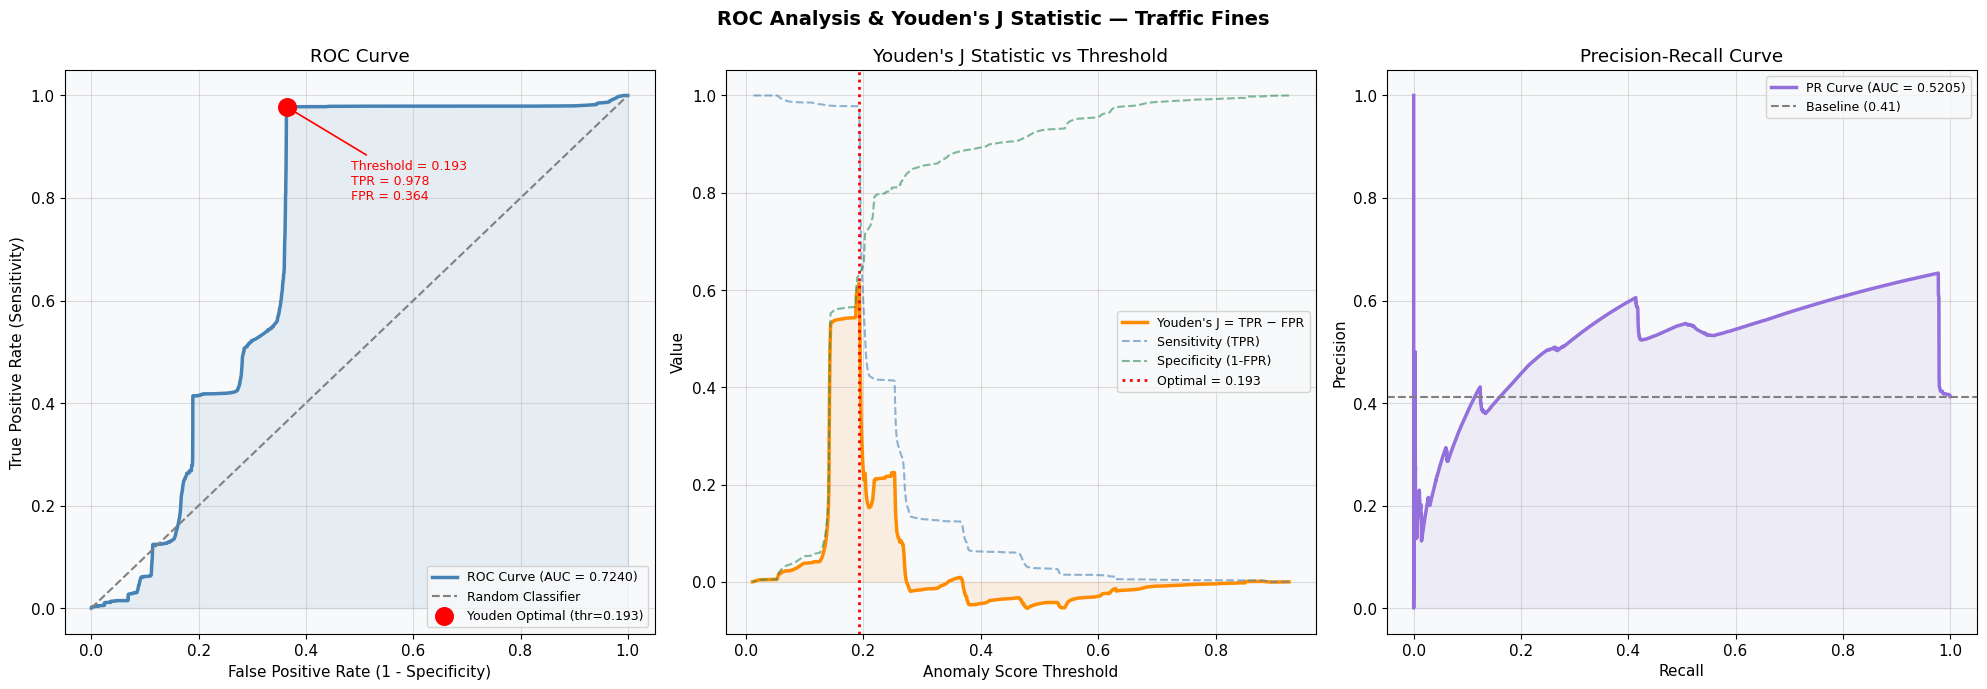

  📐 YOUDEN'S J OPTIMAL THRESHOLD SUMMARY
  Optimal Threshold   : 0.1927
  Youden's J (max)    : 0.6136
  Sensitivity (TPR)   : 0.9777
  Specificity         : 0.6360
  False Positive Rate : 0.3640
  ROC-AUC             : 0.7240
  PR-AUC              : 0.5205


In [11]:
# ── Ground truth dari label asli ────────────────────────────────────────────
y_true  = (test_df['label'] == 'deviant').astype(int).values
y_score = results_df['anomaly_score'].values

anomaly_rate = y_true.mean()
print(f"📌 Real anomaly rate (deviant): {anomaly_rate:.1%}  ({y_true.sum():,} / {len(y_true):,})")

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc              = auc(fpr, tpr)

# ── Youden's J Statistic ──────────────────────────────────────────────────────
youdens_j      = tpr - fpr
best_idx       = np.argmax(youdens_j)
best_threshold = thresholds[best_idx]
best_tpr       = tpr[best_idx]
best_fpr       = fpr[best_idx]
best_j         = youdens_j[best_idx]
best_specificity = 1 - best_fpr
best_sensitivity = best_tpr

# ── Precision-Recall AUC ─────────────────────────────────────────────────────
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("ROC Analysis & Youden's J Statistic — Traffic Fines",
             fontsize=14, fontweight='bold')

# (a) ROC Curve
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.plot([0,1],[0,1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
ax.scatter(best_fpr, best_tpr, s=160, zorder=5, color='red',
           label=f'Youden Optimal (thr={best_threshold:.3f})')
ax.annotate(
    f'Threshold = {best_threshold:.3f}\nTPR = {best_tpr:.3f}\nFPR = {best_fpr:.3f}',
    xy=(best_fpr, best_tpr),
    xytext=(best_fpr+0.12, best_tpr-0.18),
    fontsize=9, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve')
ax.legend(fontsize=9, loc='lower right')

# (b) Youden's J over thresholds
ax = axes[1]
n = len(thresholds)
ax.plot(thresholds, youdens_j[:n], color='darkorange', lw=2.5, label="Youden's J = TPR − FPR")
ax.plot(thresholds, tpr[:n],       color='steelblue',  lw=1.5, alpha=0.6, linestyle='--', label='Sensitivity (TPR)')
ax.plot(thresholds, 1-fpr[:n],     color='seagreen',   lw=1.5, alpha=0.6, linestyle='--', label='Specificity (1-FPR)')
ax.axvline(best_threshold, color='red', linestyle=':', lw=2,
           label=f'Optimal = {best_threshold:.3f}')
ax.fill_between(thresholds, youdens_j[:n], alpha=0.1, color='darkorange')
ax.set_xlabel('Anomaly Score Threshold')
ax.set_ylabel('Value')
ax.set_title("Youden's J Statistic vs Threshold")
ax.legend(fontsize=9)

# (c) Precision-Recall Curve
ax = axes[2]
ax.plot(recall, precision, color='mediumpurple', lw=2.5,
        label=f'PR Curve (AUC = {pr_auc:.4f})')
ax.fill_between(recall, precision, alpha=0.1, color='mediumpurple')
ax.axhline(anomaly_rate, color='gray', linestyle='--', lw=1.5, label=f'Baseline ({anomaly_rate:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_03_roc_youden_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("=" * 60)
print("  📐 YOUDEN'S J OPTIMAL THRESHOLD SUMMARY")
print("=" * 60)
print(f"  Optimal Threshold   : {best_threshold:.4f}")
print(f"  Youden's J (max)    : {best_j:.4f}")
print(f"  Sensitivity (TPR)   : {best_sensitivity:.4f}")
print(f"  Specificity         : {best_specificity:.4f}")
print(f"  False Positive Rate : {best_fpr:.4f}")
print(f"  ROC-AUC             : {roc_auc:.4f}")
print(f"  PR-AUC              : {pr_auc:.4f}")
print("=" * 60)

## ✅ 11. Apply Optimal Threshold & Classification Metrics

🎯 Applying Youden's optimal threshold: 0.1927

📋 Classification Report (Ground Truth = real label):
                   precision    recall  f1-score   support

 Regular (Normal)       0.98      0.64      0.77     22844
Deviant (Anomaly)       0.65      0.98      0.78     16041

         accuracy                           0.78     38885
        macro avg       0.81      0.81      0.78     38885
     weighted avg       0.84      0.78      0.78     38885

  Matthews Corr. Coef. (MCC): 0.6215
  Accuracy                  : 0.7769


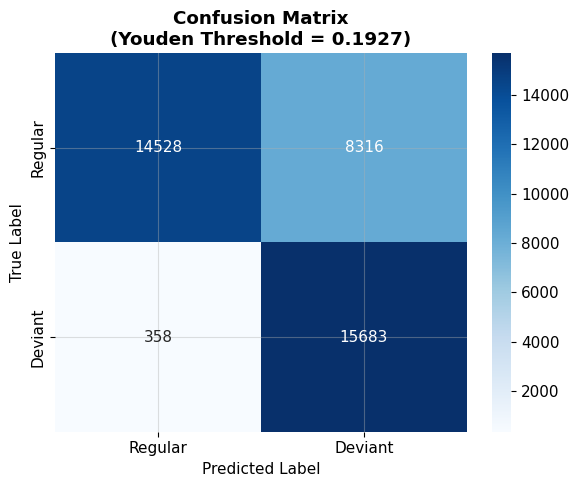

In [12]:
# Apply Youden's optimal threshold
results_df['is_anomaly_youden'] = (results_df['anomaly_score'] >= best_threshold).astype(int)

print(f"🎯 Applying Youden's optimal threshold: {best_threshold:.4f}\n")
print("📋 Classification Report (Ground Truth = real label):")
print(classification_report(y_true, results_df['is_anomaly_youden'],
                             target_names=['Regular (Normal)', 'Deviant (Anomaly)']))

mcc = matthews_corrcoef(y_true, results_df['is_anomaly_youden'])
print(f"  Matthews Corr. Coef. (MCC): {mcc:.4f}")
print(f"  Accuracy                  : {accuracy_score(y_true, results_df['is_anomaly_youden']):.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, results_df['is_anomaly_youden'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Regular','Deviant'],
            yticklabels=['Regular','Deviant'], ax=ax)
ax.set_title(f'Confusion Matrix\n(Youden Threshold = {best_threshold:.4f})', fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 📊 12. Results Dashboard — Anomaly Score Distribution & Risk Breakdown

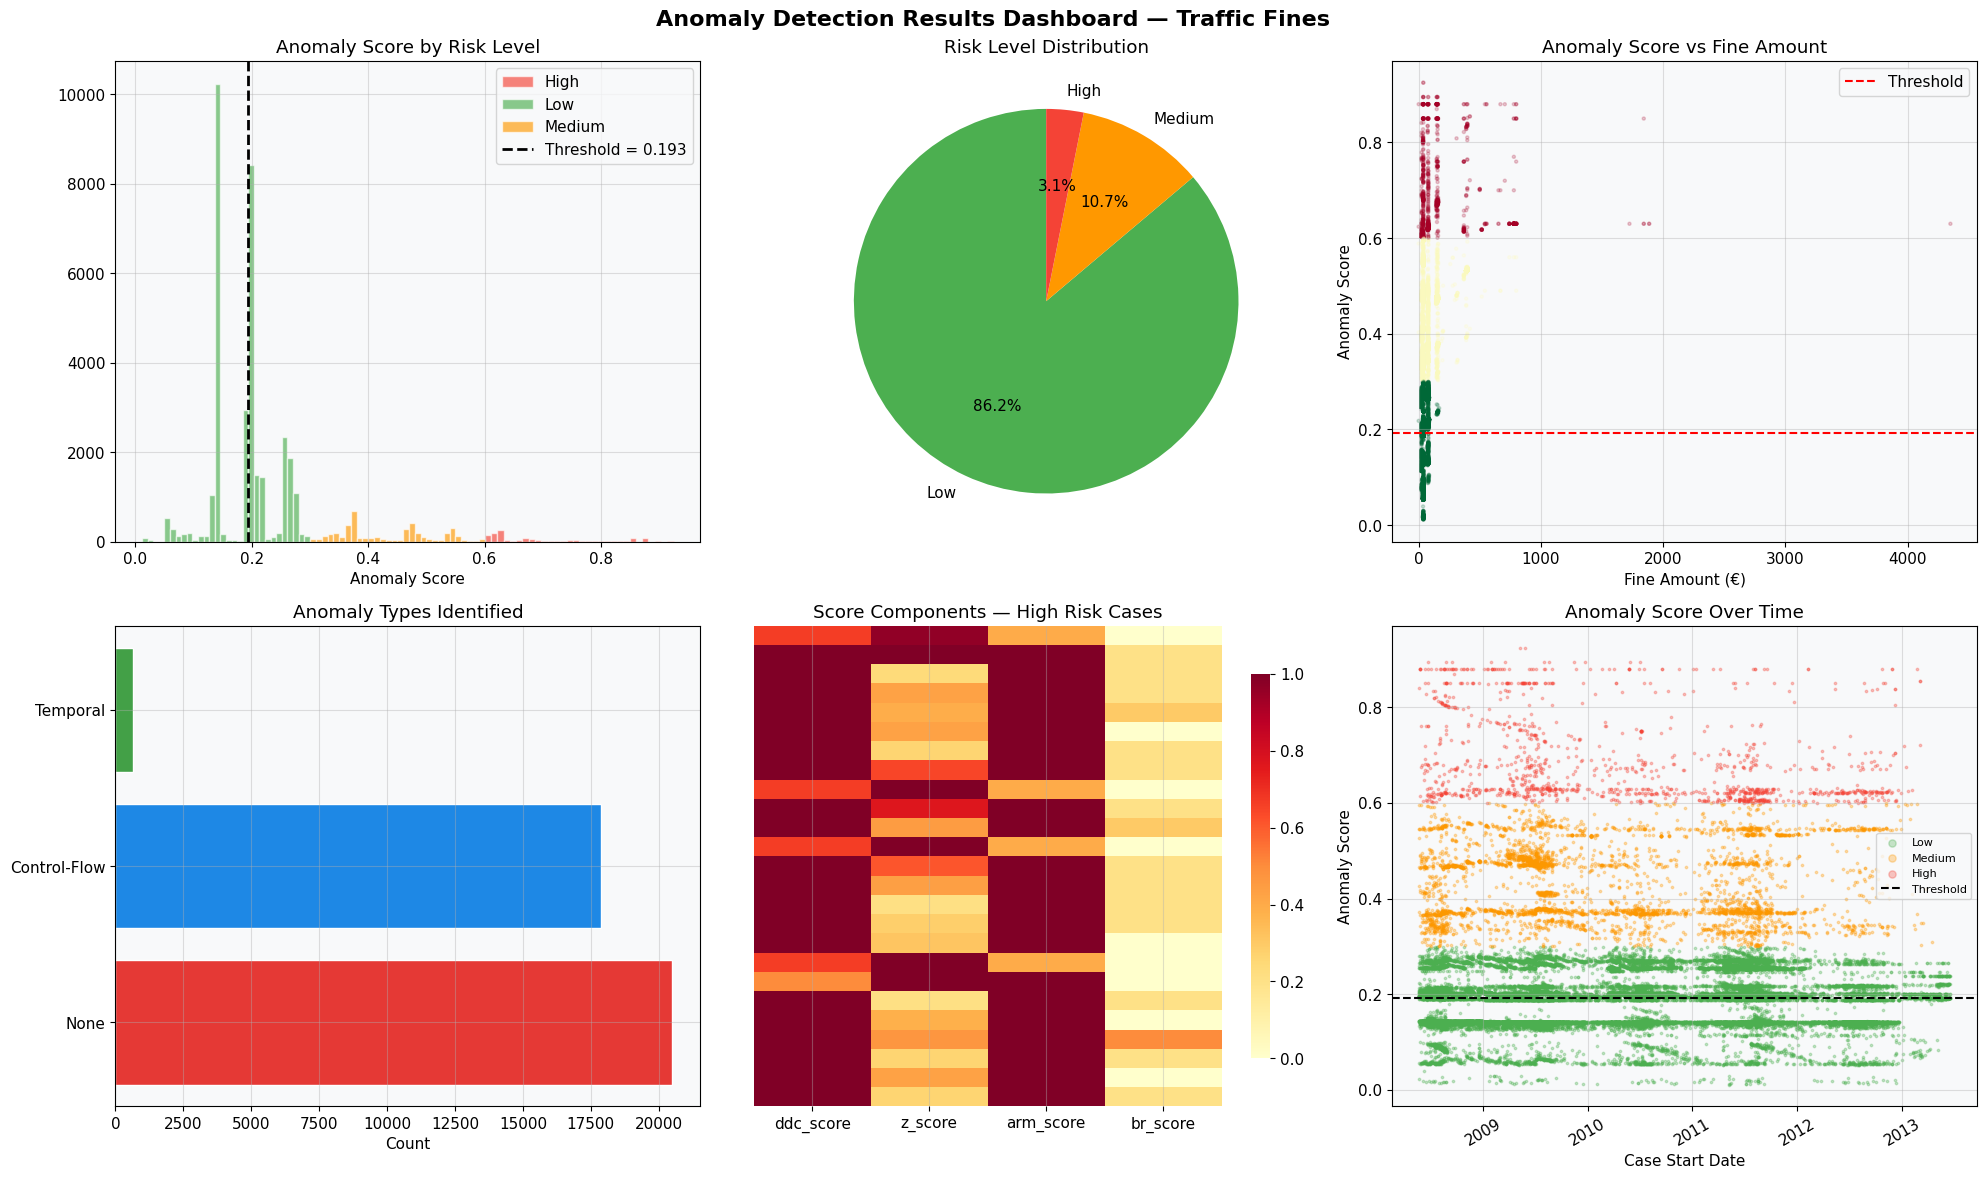

In [13]:
final_results = test_df[['case_id','vehicleClass','dismissal',
                          'amount','cf_seq_violations',
                          'temp_total_hrs','res_n_resources','label']].copy()
final_results = final_results.merge(results_df, on='case_id')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Anomaly Detection Results Dashboard — Traffic Fines', fontsize=16, fontweight='bold')

colors_risk = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

# (a) Score distribution by risk level
ax = axes[0,0]
for rl, grp in final_results.groupby('risk_level'):
    ax.hist(grp['anomaly_score'], bins=30, alpha=0.65, label=rl,
            color=colors_risk[rl], edgecolor='white')
ax.axvline(best_threshold, color='black', linestyle='--', lw=2,
           label=f'Threshold = {best_threshold:.3f}')
ax.set_title('Anomaly Score by Risk Level')
ax.set_xlabel('Anomaly Score')
ax.legend()

# (b) Risk level pie
ax = axes[0,1]
rl_counts = final_results['risk_level'].value_counts()
ax.pie(rl_counts.values, labels=rl_counts.index, autopct='%1.1f%%',
       colors=[colors_risk[k] for k in rl_counts.index], startangle=90)
ax.set_title('Risk Level Distribution')

# (c) Score vs amount
ax = axes[0,2]
sc = ax.scatter(final_results['amount'], final_results['anomaly_score'],
                c=final_results['risk_level'].map({'Low':0,'Medium':1,'High':2}),
                cmap='RdYlGn_r', alpha=0.2, s=5)
ax.axhline(best_threshold, color='red', linestyle='--', lw=1.5, label='Threshold')
ax.set_title('Anomaly Score vs Fine Amount')
ax.set_xlabel('Fine Amount (€)')
ax.set_ylabel('Anomaly Score')
ax.legend()

# (d) Anomaly type breakdown
ax = axes[1,0]
atype_counts = final_results['anomaly_types'].str.split('|').explode().value_counts()
ax.barh(atype_counts.index, atype_counts.values,
        color=['#E53935','#1E88E5','#43A047','#FB8C00'], edgecolor='white')
ax.set_title('Anomaly Types Identified')
ax.set_xlabel('Count')

# (e) Score components heatmap (sample high risk)
ax = axes[1,1]
high_risk = final_results[final_results['risk_level']=='High'].sample(
    min(25, len(final_results[final_results['risk_level']=='High'])), random_state=42)
comp_cols = ['ddc_score','z_score','arm_score','br_score']
if len(high_risk) > 0:
    sns.heatmap(high_risk[comp_cols].values, ax=ax, cmap='YlOrRd',
                xticklabels=comp_cols, yticklabels=False, cbar_kws={'shrink':0.8})
ax.set_title('Score Components — High Risk Cases')

# (f) Anomaly score over time
ax = axes[1,2]
time_merged = test_df[['case_id','start_time']].merge(
    results_df[['case_id','anomaly_score','risk_level']], on='case_id')
time_merged = time_merged.sort_values('start_time')
for rl, color in colors_risk.items():
    sub = time_merged[time_merged['risk_level']==rl]
    ax.scatter(sub['start_time'], sub['anomaly_score'], s=3, alpha=0.3,
               color=color, label=rl)
ax.axhline(best_threshold, color='black', linestyle='--', lw=1.5, label='Threshold')
ax.set_title('Anomaly Score Over Time')
ax.set_xlabel('Case Start Date')
ax.set_ylabel('Anomaly Score')
ax.legend(markerscale=3, fontsize=8)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_05_results_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 13. Export Results

In [14]:
export_df = final_results.copy()
export_df['is_anomaly']   = (export_df['anomaly_score'] >= best_threshold).astype(int)
export_df['ground_truth'] = (export_df['label'] == 'deviant').astype(int)
export_df = export_df.sort_values('anomaly_score', ascending=False)

export_df.to_csv(OUTPUT_DIR / 'tf_anomaly_detection_results.csv', index=False)

print(f"✅ Results exported to: {OUTPUT_DIR / 'tf_anomaly_detection_results.csv'}")
print(f"\n📊 Final Summary:")
print(f"   Total cases scored   : {len(export_df):,}")
print(f"   Detected as anomaly  : {export_df['is_anomaly'].sum():,}  ({export_df['is_anomaly'].mean():.1%})")
print(f"   True deviant (label) : {export_df['ground_truth'].sum():,}  ({export_df['ground_truth'].mean():.1%})")
print(f"   High risk            : {(export_df['risk_level']=='High').sum():,}")
print(f"   Medium risk          : {(export_df['risk_level']=='Medium').sum():,}")
print(f"   Low risk             : {(export_df['risk_level']=='Low').sum():,}")
print(f"\n   Optimal threshold    : {best_threshold:.4f}  (Youden's J)")
print(f"   ROC-AUC              : {roc_auc:.4f}")
print(f"   Sensitivity          : {best_sensitivity:.4f}")
print(f"   Specificity          : {best_specificity:.4f}")
print(f"   MCC                  : {mcc:.4f}")

print("\n📋 Top 10 Most Anomalous Cases:")
export_df[['case_id','anomaly_score','risk_level','anomaly_types',
           'label','explanation','amount']].head(10)

✅ Results exported to: dataOutput/tf_anomaly_detection_results.csv

📊 Final Summary:
   Total cases scored   : 38,885
   Detected as anomaly  : 23,999  (61.7%)
   True deviant (label) : 16,041  (41.3%)
   High risk            : 1,219
   Medium risk          : 4,162
   Low risk             : 33,504

   Optimal threshold    : 0.1927  (Youden's J)
   ROC-AUC              : 0.7240
   Sensitivity          : 0.9777
   Specificity          : 0.6360
   MCC                  : 0.6215

📋 Top 10 Most Anomalous Cases:


,case_id,anomaly_score,risk_level,anomaly_types,label,explanation,amount
11624,S137407,0.925,High,Control-Flow|Temporal,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,38.0
11068,S136885,0.925,High,Control-Flow|Temporal,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,38.0
4831,V17561,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,148.0
5452,V17677,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,148.0
1074,A26902,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,36.0
9549,V18348,0.895,High,Control-Flow|Temporal,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,155.0
18609,S143166,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,38.0
21966,S154697,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,78.0
15446,A44928,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,38.0
16371,S141999,0.895,High,Control-Flow,regular,DDC violations: DDC_Z:cf_seq_violations; DDC_I...,150.0


## 💾 14. Simpan Model ke File
> Semua objek model (Digital Twin, DDC, MV-ARM, Intelligent Body) disimpan ke `dataOutput/` agar bisa dipanggil ulang tanpa re-training.

In [15]:
import pickle

# ── Kemas semua yang dibutuhkan untuk inference ───────────────────────────────
model_bundle = {
    'digital_twin'    : dt,
    'ddc'             : ddc,
    'mv_arm'          : mva,
    'intelligent_body': ib,
    'scaler'          : scaler,
    'best_threshold'  : best_threshold,
    'NUMERIC_COLS'    : NUMERIC_COLS,
    'ACTIVITY_ORDER'  : ACTIVITY_ORDER,
    'activity_rank'   : activity_rank,
    'roc_auc'         : roc_auc,
    'best_sensitivity': best_sensitivity,
    'best_specificity': best_specificity,
}

MODEL_PATH = OUTPUT_DIR / 'model/tf_model_bundle.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"✅ Model bundle disimpan ke: {MODEL_PATH.resolve()}")
print(f"\n📦 Isi bundle:")
for k, v in model_bundle.items():
    print(f"   {k:<20s}: {type(v).__name__}")

✅ Model bundle disimpan ke: /Users/mac/Documents/Deinony/Project/Aritificial Intelligence/DeteksiAnomaliBisnis/sendSample/dataOutput/model/tf_model_bundle.pkl

📦 Isi bundle:
   digital_twin        : DigitalTwin
   ddc                 : DynamicDeclarativeConstraints
   mv_arm              : MVARMiner
   intelligent_body    : IntelligentBody
   scaler              : StandardScaler
   best_threshold      : float64
   NUMERIC_COLS        : list
   ACTIVITY_ORDER      : list
   activity_rank       : dict
   roc_auc             : float64
   best_sensitivity    : float64
   best_specificity    : float64


## 🧪 14. Testing dengan Dummy Data (10 Kasus)
> Simulasi pipeline secara end-to-end menggunakan 10 kasus buatan dengan karakteristik bervariasi:  
> - **Regular** → semua fitur dalam batas normal  
> - **Deviant ringan** → 1–2 sinyal pelanggaran  
> - **Deviant berat** → sequence violation, amount tinggi, durasi ekstrem, appeal tanpa payment, dsb.

In [16]:
# ── Buat 10 dummy cases ───────────────────────────────────────────────────────
dummy_data = pd.DataFrame({
    'case_id'             : [f'DUMMY_{i:03d}' for i in range(1, 11)],
    # Control flow
    'cf_seq_violations'   : [0, 0, 1, 0, 3, 0, 2, 0, 1, 0],
    'cf_missing_steps'    : [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    'cf_duplicate_steps'  : [0, 1, 0, 0, 2, 0, 3, 0, 0, 0],
    'cf_n_events'         : [3, 4, 2, 5, 1, 3, 7, 3, 4, 3],
    'cf_has_payment'      : [1, 1, 0, 1, 0, 1, 0, 1, 1, 1],
    'cf_has_appeal'       : [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    'cf_has_penalty'      : [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    # Temporal
    'temp_total_hrs'      : [720.0, 1440.0, 0.5, 2160.0, 8760.0, 960.0, 480.0, 840.0, 3600.0, 1200.0],
    'temp_mean_step_hrs'  : [360.0, 480.0,  0.25, 540.0, 2920.0, 320.0, 80.0,  280.0, 900.0,  400.0],
    'temp_std_step_hrs'   : [50.0,  80.0,   0.1,  100.0, 500.0,  60.0,  120.0, 40.0,  200.0,  70.0],
    'temp_max_step_hrs'   : [500.0, 900.0,  0.4,  1200.0,5000.0, 700.0, 300.0, 600.0, 2000.0, 800.0],
    # Resource
    'res_n_resources'     : [1, 1, 1, 2, 5, 1, 4, 1, 2, 1],
    'res_rpa_flag'        : [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    # Attributes
    'amount'              : [35.0, 71.5, 250.0, 35.0, 500.0, 71.5, 35.0, 35.0, 150.0, 71.5],
    'points'              : [0.0,  0.0,  2.0,   0.0,  5.0,   0.0,  3.0,  0.0,  1.0,   0.0],
    'expense'             : [11.0, 22.0, 0.0,   33.0, 100.0, 11.0, 55.0, 11.0, 44.0,  22.0],
    # Meta
    'vehicleClass'        : ['A','A','B','A','C','A','B','A','A','A'],
    'dismissal'           : ['NIL','NIL','NIL','NIL','NIL','NIL','G','NIL','NIL','NIL'],
    'label'               : ['regular','regular','deviant','regular','deviant',
                              'regular','deviant','regular','deviant','regular'],
})

case_descriptions = [
    'Regular — proses normal, bayar denda',
    'Regular — ada penalty, proses sedikit lama',
    'Deviant: proses sangat cepat (0.5 jam) + denda tinggi + no payment',
    'Regular — 5 event, 2 resource, bayar',
    'Deviant berat: 3 seq-violation, missing step, 5 resource, appeal tanpa bayar, denda €500',
    'Regular — RPA terlibat, proses normal',
    'Deviant: 2 seq-violation, 3 duplikat, 4 resource, appeal tanpa bayar',
    'Regular — standar minimal',
    'Deviant ringan: durasi lama, 2 resource, amount tinggi',
    'Regular — standar',
]
dummy_data['description'] = case_descriptions

print("📋 Dummy Data (10 kasus):")
# display(dummy_data[['case_id','description','cf_seq_violations','cf_missing_steps',
#                      'temp_total_hrs','amount','res_n_resources','label']].to_string(index=False))
dummy_data

📋 Dummy Data (10 kasus):


,case_id,cf_seq_violations,cf_missing_steps,cf_duplicate_steps,cf_n_events,cf_has_payment,cf_has_appeal,cf_has_penalty,temp_total_hrs,temp_mean_step_hrs,...,temp_max_step_hrs,res_n_resources,res_rpa_flag,amount,points,expense,vehicleClass,dismissal,label,description
0,DUMMY_001,0,0,0,3,1,0,0,720.0,360.00,...,500.0,1,0,35.0,0.0,11.0,A,NIL,regular,"Regular — proses normal, bayar denda"
1,DUMMY_002,0,0,1,4,1,0,1,1440.0,480.00,...,900.0,1,0,71.5,0.0,22.0,A,NIL,regular,"Regular — ada penalty, proses sedikit lama"
2,DUMMY_003,1,0,0,2,0,0,0,0.5,0.25,...,0.4,1,1,250.0,2.0,0.0,B,NIL,deviant,Deviant: proses sangat cepat (0.5 jam) + denda...
3,DUMMY_004,0,0,0,5,1,0,1,2160.0,540.00,...,1200.0,2,0,35.0,0.0,33.0,A,NIL,regular,"Regular — 5 event, 2 resource, bayar"
4,DUMMY_005,3,1,2,1,0,1,1,8760.0,2920.00,...,5000.0,5,0,500.0,5.0,100.0,C,NIL,deviant,"Deviant berat: 3 seq-violation, missing step, ..."
5,DUMMY_006,0,0,0,3,1,0,0,960.0,320.00,...,700.0,1,1,71.5,0.0,11.0,A,NIL,regular,"Regular — RPA terlibat, proses normal"
6,DUMMY_007,2,1,3,7,0,1,1,480.0,80.00,...,300.0,4,0,35.0,3.0,55.0,B,G,deviant,"Deviant: 2 seq-violation, 3 duplikat, 4 resour..."
7,DUMMY_008,0,0,0,3,1,0,0,840.0,280.00,...,600.0,1,0,35.0,0.0,11.0,A,NIL,regular,Regular — standar minimal
8,DUMMY_009,1,0,0,4,1,0,1,3600.0,900.00,...,2000.0,2,0,150.0,1.0,44.0,A,NIL,deviant,"Deviant ringan: durasi lama, 2 resource, amoun..."
9,DUMMY_010,0,0,0,3,1,0,0,1200.0,400.00,...,800.0,1,0,71.5,0.0,22.0,A,NIL,regular,Regular — standar


In [17]:
# ── Scoring dummy data ───────────────────────────────────────────────────────
dummy_results = ib.score_all(dummy_data)
dummy_results['description'] = case_descriptions
dummy_results['true_label']  = dummy_data['label'].values

dummy_final = dummy_data[['case_id','cf_seq_violations','cf_missing_steps',
                            'temp_total_hrs','amount','res_n_resources','label']].merge(
    dummy_results[['case_id','anomaly_score','risk_level','anomaly_types',
                   'ddc_score','z_score','arm_score','br_score',
                   'ddc_violations','arm_rules_hit','explanation']],
    on='case_id'
)
dummy_final.insert(1, 'description', case_descriptions)

# ── Tabel hasil ──────────────────────────────────────────────────────────────
print("=" * 110)
print("  🔍 HASIL SCORING DUMMY DATA — 10 KASUS")
print("=" * 110)

RISK_ICON = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}
for _, row in dummy_final.iterrows():
    icon = RISK_ICON[row['risk_level']]
    flag = '⚠️  DEVIANT' if row['anomaly_score'] >= best_threshold else '   regular'
    true_lbl = row['label']
    match = '✅' if (row['anomaly_score'] >= best_threshold) == (true_lbl == 'deviant') else '❌'
    print(f"\n{icon} [{row['case_id']}] {row['description']}")
    print(f"   True Label : {true_lbl:8s}  |  Predicted: {flag}  {match}")
    print(f"   Score      : {row['anomaly_score']:.4f}  (threshold = {best_threshold:.4f})")
    print(f"   Risk Level : {row['risk_level']}")
    print(f"   Tipe       : {row['anomaly_types']}")
    print(f"   Komponen   : DDC={row['ddc_score']:.3f} | Z={row['z_score']:.3f} | ARM={row['arm_score']:.3f} | BR={row['br_score']:.3f}")
    print(f"   Penjelasan : {row['explanation']}")

print("\n" + "=" * 110)

  🔍 HASIL SCORING DUMMY DATA — 10 KASUS

🟢 [DUMMY_001] Regular — proses normal, bayar denda
   True Label : regular   |  Predicted:    regular  ✅
   Score      : 0.0297  (threshold = 0.1927)
   Risk Level : Low
   Tipe       : None
   Komponen   : DDC=0.000 | Z=0.085 | ARM=0.000 | BR=0.000
   Penjelasan : No significant deviations detected

🟡 [DUMMY_002] Regular — ada penalty, proses sedikit lama
   True Label : regular   |  Predicted: ⚠️  DEVIANT  ❌
   Score      : 0.3430  (threshold = 0.1927)
   Risk Level : Medium
   Tipe       : None
   Komponen   : DDC=0.333 | Z=0.123 | ARM=1.000 | BR=0.000
   Penjelasan : DDC violations: DDC_IQR:cf_duplicate_steps; DDC_IQR:amount | MV-ARM rule triggered: cf view

🔴 [DUMMY_003] Deviant: proses sangat cepat (0.5 jam) + denda tinggi + no payment
   True Label : deviant   |  Predicted: ⚠️  DEVIANT  ✅
   Score      : 0.7266  (threshold = 0.1927)
   Risk Level : High
   Tipe       : Control-Flow
   Komponen   : DDC=1.000 | Z=0.633 | ARM=0.800 | BR=0.30

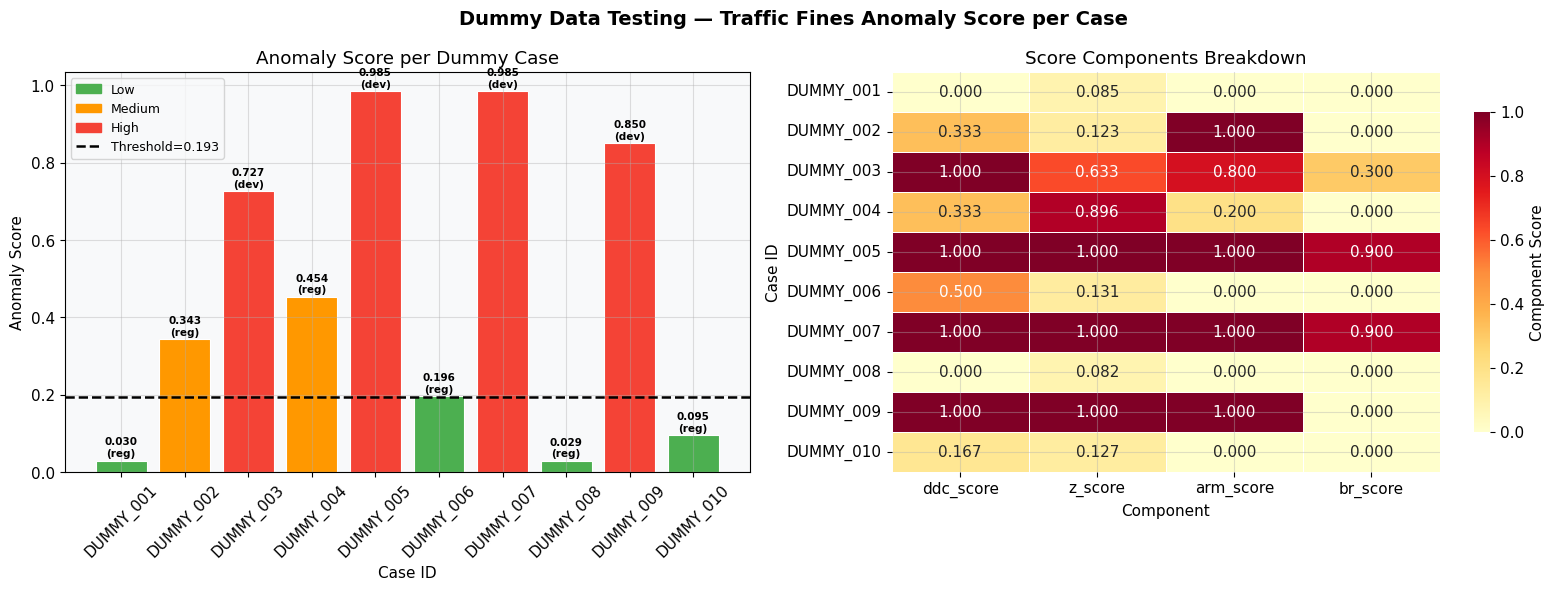

✅ Visualisasi dummy test selesai. Disimpan ke tf_14_dummy_test_results.png


In [18]:
# ── Visualisasi hasil dummy ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dummy Data Testing — Traffic Fines Anomaly Score per Case',
             fontsize=14, fontweight='bold')

colors_risk = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
bar_colors  = [colors_risk[r] for r in dummy_final['risk_level']]

# (a) Bar chart anomaly score
ax = axes[0]
bars = ax.bar(dummy_final['case_id'], dummy_final['anomaly_score'],
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(best_threshold, color='black', linestyle='--', lw=1.8,
           label=f'Threshold = {best_threshold:.3f}')
ax.set_title('Anomaly Score per Dummy Case')
ax.set_xlabel('Case ID')
ax.set_ylabel('Anomaly Score')
ax.set_ylim(0, max(dummy_final['anomaly_score'].max() + 0.05, best_threshold + 0.1))
ax.tick_params(axis='x', rotation=45)

# Annotate bar values + true label
for bar, score, lbl in zip(bars, dummy_final['anomaly_score'], dummy_final['label']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}\n({lbl[:3]})', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

patches = [mpatches.Patch(color=c, label=l) for l, c in colors_risk.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='black', linestyle='--', lw=1.8,
           label=f'Threshold={best_threshold:.3f}')], fontsize=9)

# (b) Heatmap komponen score
ax = axes[1]
score_components = dummy_final[['case_id','ddc_score','z_score','arm_score','br_score']].set_index('case_id')
sns.heatmap(score_components, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Component Score', 'shrink': 0.8})
ax.set_title('Score Components Breakdown')
ax.set_xlabel('Component')
ax.set_ylabel('Case ID')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tf_14_dummy_test_results.png', dpi=120, bbox_inches='tight')
plt.show()

print("✅ Visualisasi dummy test selesai. Disimpan ke tf_14_dummy_test_results.png")

---
## 🧪 15. Klasifikasi Sampel Dummy Baru — Pakai Model Tersimpan
> **Load model** dari file → buat **10 sampel event log** mirip `traffic_fines_1.csv` → jalankan pipeline penuh → tampilkan hasil klasifikasi.
>
> Format data mengikuti skema raw event log (multi-baris per kasus) sebelum feature extraction.

In [19]:
import pickle
from pathlib import Path

# ── Load model bundle ─────────────────────────────────────────────────────────
MODEL_PATH = Path('dataOutput') / 'model/tf_model_bundle.pkl'
with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

dt_loaded         = bundle['digital_twin']
ddc_loaded        = bundle['ddc']
mva_loaded        = bundle['mv_arm']
ib_loaded         = bundle['intelligent_body']
scaler_loaded     = bundle['scaler']
threshold_loaded  = bundle['best_threshold']
NUMERIC_COLS_L    = bundle['NUMERIC_COLS']
ACTIVITY_ORDER_L  = bundle['ACTIVITY_ORDER']
activity_rank_L   = bundle['activity_rank']

print(f"✅ Model bundle loaded dari: {MODEL_PATH.resolve()}")
print(f"   Threshold  : {threshold_loaded:.4f}")
print(f"   ROC-AUC    : {bundle['roc_auc']:.4f}")
print(f"   Sensitivity: {bundle['best_sensitivity']:.4f}")
print(f"   Specificity: {bundle['best_specificity']:.4f}")

✅ Model bundle loaded dari: /Users/mac/Documents/Deinony/Project/Aritificial Intelligence/DeteksiAnomaliBisnis/sendSample/dataOutput/model/tf_model_bundle.pkl
   Threshold  : 0.1927
   ROC-AUC    : 0.7240
   Sensitivity: 0.9777
   Specificity: 0.6360


In [20]:
import pandas as pd
import numpy as np

# ── 10 Sampel Raw Event Log (format mirip traffic_fines_1.csv) ───────────────
# Kolom: article, vehicleClass, amount, points, Case ID, Activity, Resource,
#        lastSent, notificationType, dismissal, expense, Complete Timestamp, label
# Setiap baris = 1 event. Satu kasus bisa punya beberapa event (baris).

raw_dummy_events = [
    # ── CASE D001 — Regular: Create Fine → Send Fine → Payment (normal) ──
    ('A001','A', 35.0, 0,'D001','Create Fine',           'Police-1',  'NIL','P',  'NIL', 0.0, '2024-01-05 08:00:00','regular'),
    ('A001','A', 35.0, 0,'D001','Send Fine',             'Police-1',  'NIL','P',  'NIL', 0.0, '2024-02-10 10:00:00','regular'),
    ('A001','A', 35.0, 0,'D001','Payment',               'Bank-1',    'NIL','P',  'NIL',11.0, '2024-03-15 14:00:00','regular'),

    # ── CASE D002 — Regular: lengkap dengan Add penalty sebelum Payment ──
    ('A002','B', 71.5, 2,'D002','Create Fine',           'Police-2',  'NIL','P',  'NIL', 0.0, '2024-01-10 09:00:00','regular'),
    ('A002','B', 71.5, 2,'D002','Send Fine',             'Police-2',  'NIL','P',  'NIL', 0.0, '2024-02-20 11:00:00','regular'),
    ('A002','B', 71.5, 2,'D002','Insert Fine Notification','0',       'NIL','P',  'NIL', 0.0, '2024-03-01 09:30:00','regular'),
    ('A002','B', 71.5, 2,'D002','Add penalty',           'Police-2',  'NIL','P',  'NIL',22.0, '2024-04-05 16:00:00','regular'),
    ('A002','B', 71.5, 2,'D002','Payment',               'Bank-2',    'NIL','P',  'NIL',22.0, '2024-05-10 13:00:00','regular'),

    # ── CASE D003 — Deviant: proses sangat cepat (< 1 jam), tidak ada Payment ──
    ('A003','C',250.0, 3,'D003','Create Fine',           'Police-3',  'NIL','P',  'NIL', 0.0, '2024-01-15 08:00:00','deviant'),
    ('A003','C',250.0, 3,'D003','Send Fine',             'Police-3',  'NIL','P',  'NIL', 0.0, '2024-01-15 08:25:00','deviant'),

    # ── CASE D004 — Regular: proses normal dengan 2 resource berbeda ──
    ('A004','A', 35.0, 0,'D004','Create Fine',           'Police-1',  'NIL','P',  'NIL', 0.0, '2024-02-01 08:00:00','regular'),
    ('A004','A', 35.0, 0,'D004','Send Fine',             'Police-1',  'NIL','P',  'NIL', 0.0, '2024-03-01 10:00:00','regular'),
    ('A004','A', 35.0, 0,'D004','Add penalty',           'Police-4',  'NIL','P',  'NIL',11.0, '2024-05-01 09:00:00','regular'),
    ('A004','A', 35.0, 0,'D004','Payment',               'Bank-3',    'NIL','P',  'NIL',11.0, '2024-06-15 15:00:00','regular'),
    ('A004','A', 35.0, 0,'D004','Send Fine',             'Police-1',  'NIL','P',  'NIL',11.0, '2024-07-01 12:00:00','regular'),

    # ── CASE D005 — Deviant berat: urutan terbalik + appeal tanpa Payment ──
    ('A005','C',500.0, 5,'D005','Add penalty',           'Police-5',  'NIL','P',  'NIL', 0.0, '2024-01-20 08:00:00','deviant'),
    ('A005','C',500.0, 5,'D005','Create Fine',           'Police-5',  'NIL','P',  'NIL', 0.0, '2024-02-10 09:00:00','deviant'),
    ('A005','C',500.0, 5,'D005','Send Fine',             'Police-5',  'NIL','P',  'NIL', 0.0, '2024-03-15 10:00:00','deviant'),
    ('A005','C',500.0, 5,'D005','Insert Date Appeal to Prefecture','Police-5','NIL','P','NIL',100.0,'2024-06-01 11:00:00','deviant'),
    ('A005','C',500.0, 5,'D005','Send Appeal to Prefecture','Court-1','NIL','P',  'NIL',100.0, '2024-08-01 14:00:00','deviant'),
    ('A005','C',500.0, 5,'D005','Appeal to Judge',       'Court-2',   'NIL','P',  'G',  100.0, '2025-01-10 16:00:00','deviant'),

    # ── CASE D006 — Regular: hanya Create Fine → Payment (singkat tapi valid) ──
    ('A006','A', 71.5, 0,'D006','Create Fine',           '0',         'NIL','P',  'NIL', 0.0, '2024-03-01 08:00:00','regular'),
    ('A006','A', 71.5, 0,'D006','Send Fine',             '0',         'NIL','P',  'NIL', 0.0, '2024-04-10 09:00:00','regular'),
    ('A006','A', 71.5, 0,'D006','Payment',               'Bank-1',    'NIL','P',  'NIL',11.0, '2024-05-20 11:00:00','regular'),

    # ── CASE D007 — Deviant: banyak duplikat Add penalty + 4 resource ──
    ('A007','B', 35.0, 3,'D007','Create Fine',           'Police-1',  'NIL','P',  'NIL', 0.0, '2024-02-15 08:00:00','deviant'),
    ('A007','B', 35.0, 3,'D007','Send Fine',             'Police-2',  'NIL','P',  'NIL', 0.0, '2024-03-20 10:00:00','deviant'),
    ('A007','B', 35.0, 3,'D007','Add penalty',           'Police-3',  'NIL','P',  'NIL',22.0, '2024-05-01 12:00:00','deviant'),
    ('A007','B', 35.0, 3,'D007','Add penalty',           'Police-4',  'NIL','P',  'NIL',22.0, '2024-07-01 14:00:00','deviant'),
    ('A007','B', 35.0, 3,'D007','Add penalty',           'Police-5',  'NIL','P',  'NIL',22.0, '2024-09-01 16:00:00','deviant'),
    ('A007','B', 35.0, 3,'D007','Insert Date Appeal to Prefecture','Court-1','NIL','P','G',55.0,'2025-01-01 10:00:00','deviant'),

    # ── CASE D008 — Regular: standar minimal 3 event ──
    ('A008','A', 35.0, 0,'D008','Create Fine',           'Police-1',  'NIL','P',  'NIL', 0.0, '2024-04-01 08:00:00','regular'),
    ('A008','A', 35.0, 0,'D008','Send Fine',             'Police-1',  'NIL','P',  'NIL', 0.0, '2024-05-05 09:00:00','regular'),
    ('A008','A', 35.0, 0,'D008','Payment',               'Bank-1',    'NIL','P',  'NIL',11.0, '2024-06-10 13:00:00','regular'),

    # ── CASE D009 — Deviant ringan: durasi sangat lama (> 2 tahun) + denda besar ──
    ('A009','A',150.0, 1,'D009','Create Fine',           'Police-3',  'NIL','P',  'NIL', 0.0, '2022-01-01 08:00:00','deviant'),
    ('A009','A',150.0, 1,'D009','Send Fine',             'Police-3',  'NIL','P',  'NIL', 0.0, '2022-06-15 10:00:00','deviant'),
    ('A009','A',150.0, 1,'D009','Add penalty',           'Police-3',  'NIL','P',  'NIL',44.0, '2023-01-20 14:00:00','deviant'),
    ('A009','A',150.0, 1,'D009','Payment',               'Bank-2',    'NIL','P',  'NIL',44.0, '2024-06-01 16:00:00','deviant'),

    # ── CASE D010 — Regular: proses normal semua tahap lengkap ──
    ('A010','A', 71.5, 0,'D010','Create Fine',           'Police-2',  'NIL','P',  'NIL', 0.0, '2024-05-01 08:00:00','regular'),
    ('A010','A', 71.5, 0,'D010','Send Fine',             'Police-2',  'NIL','P',  'NIL', 0.0, '2024-06-10 09:00:00','regular'),
    ('A010','A', 71.5, 0,'D010','Insert Fine Notification','0',       'NIL','P',  'NIL', 0.0, '2024-07-01 10:00:00','regular'),
    ('A010','A', 71.5, 0,'D010','Add penalty',           'Police-2',  'NIL','P',  'NIL',22.0, '2024-08-15 11:00:00','regular'),
    ('A010','A', 71.5, 0,'D010','Payment',               'Bank-3',    'NIL','P',  'NIL',22.0, '2024-09-20 13:00:00','regular'),
]

COLS = ['article','vehicleClass','amount','points','Case ID','Activity','Resource',
        'lastSent','notificationType','dismissal','expense','Complete Timestamp','label']

df_new_raw = pd.DataFrame(raw_dummy_events, columns=COLS)

# Rename agar konsisten dengan pipeline
df_new_raw = df_new_raw.rename(columns={
    'Case ID'           : 'case_id',
    'Activity'          : 'activity_name',
    'Complete Timestamp': 'timestamp',
    'Resource'          : 'resource',
})

print(f"📋 New dummy event log: {df_new_raw.shape[0]} events, {df_new_raw['case_id'].nunique()} cases")
print(f"🏷️  Label              : {df_new_raw.drop_duplicates('case_id')['label'].value_counts().to_dict()}")
df_new_raw.head(12)

📋 New dummy event log: 42 events, 10 cases
🏷️  Label              : {'regular': 6, 'deviant': 4}


,article,vehicleClass,amount,points,case_id,activity_name,resource,lastSent,notificationType,dismissal,expense,timestamp,label
0,A001,A,35.0,0,D001,Create Fine,Police-1,NIL,P,NIL,0.0,2024-01-05 08:00:00,regular
1,A001,A,35.0,0,D001,Send Fine,Police-1,NIL,P,NIL,0.0,2024-02-10 10:00:00,regular
2,A001,A,35.0,0,D001,Payment,Bank-1,NIL,P,NIL,11.0,2024-03-15 14:00:00,regular
3,A002,B,71.5,2,D002,Create Fine,Police-2,NIL,P,NIL,0.0,2024-01-10 09:00:00,regular
4,A002,B,71.5,2,D002,Send Fine,Police-2,NIL,P,NIL,0.0,2024-02-20 11:00:00,regular
5,A002,B,71.5,2,D002,Insert Fine Notification,0,NIL,P,NIL,0.0,2024-03-01 09:30:00,regular
6,A002,B,71.5,2,D002,Add penalty,Police-2,NIL,P,NIL,22.0,2024-04-05 16:00:00,regular
7,A002,B,71.5,2,D002,Payment,Bank-2,NIL,P,NIL,22.0,2024-05-10 13:00:00,regular
8,A003,C,250.0,3,D003,Create Fine,Police-3,NIL,P,NIL,0.0,2024-01-15 08:00:00,deviant
9,A003,C,250.0,3,D003,Send Fine,Police-3,NIL,P,NIL,0.0,2024-01-15 08:25:00,deviant


In [21]:
# ── Feature extraction (fungsi yang sama dengan pipeline utama) ───────────────
def extract_case_features_new(grp, activity_rank_map):
    grp = grp.sort_values('timestamp')
    activities = grp['activity_name'].tolist()
    timestamps = grp['timestamp'].tolist()
    n = len(activities)

    expected_seq = [activity_rank_map.get(a, -1) for a in activities]
    seq_violations = sum(
        1 for i in range(1, len(expected_seq))
        if expected_seq[i] != -1 and expected_seq[i-1] != -1 and expected_seq[i] < expected_seq[i-1]
    )
    missing_steps   = len({'Create Fine', 'Send Fine'} - set(activities))
    duplicate_steps = n - len(set(activities))
    has_payment = int('Payment' in activities)
    has_appeal  = int(any('Appeal' in a for a in activities))
    has_penalty = int('Add penalty' in activities)

    valid_ts = [t for t in timestamps if pd.notna(t)]
    if len(valid_ts) > 1:
        durations = [(valid_ts[i+1] - valid_ts[i]).total_seconds() / 3600
                     for i in range(len(valid_ts) - 1)]
        total_duration_hrs = (valid_ts[-1] - valid_ts[0]).total_seconds() / 3600
        mean_step_dur = np.mean(durations)
        std_step_dur  = np.std(durations) if len(durations) > 1 else 0
        max_step_dur  = np.max(durations)
    else:
        durations, total_duration_hrs = [0], 0
        mean_step_dur = std_step_dur = max_step_dur = 0

    resources = grp['resource'].dropna().nunique()
    rpa_flag  = int((grp['resource'] == '0').any() or (grp['resource'] == 0).any())

    amount  = pd.to_numeric(grp['amount'].iloc[0],  errors='coerce')
    points  = pd.to_numeric(grp['points'].iloc[0],  errors='coerce')
    expense = pd.to_numeric(grp['expense'].dropna().sum(), errors='coerce')

    return pd.Series({
        'cf_seq_violations' : seq_violations,
        'cf_missing_steps'  : missing_steps,
        'cf_duplicate_steps': duplicate_steps,
        'cf_n_events'       : n,
        'cf_has_payment'    : has_payment,
        'cf_has_appeal'     : has_appeal,
        'cf_has_penalty'    : has_penalty,
        'temp_total_hrs'    : total_duration_hrs,
        'temp_mean_step_hrs': mean_step_dur,
        'temp_std_step_hrs' : std_step_dur,
        'temp_max_step_hrs' : max_step_dur,
        'res_n_resources'   : resources,
        'res_rpa_flag'      : rpa_flag,
        'amount'            : amount if pd.notna(amount) else 0,
        'points'            : points  if pd.notna(points)  else 0,
        'expense'           : expense if pd.notna(expense) else 0,
        'vehicleClass'      : grp['vehicleClass'].iloc[0],
        'dismissal'         : grp['dismissal'].iloc[0],
        'label'             : grp['label'].iloc[0],
    })

# ── Parse timestamp & extract features ───────────────────────────────────────
df_new = df_new_raw.copy()
df_new['timestamp'] = pd.to_datetime(df_new['timestamp'], errors='coerce')
df_new = df_new.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

new_features = (
    df_new.groupby('case_id')
          .apply(extract_case_features_new, activity_rank_map=activity_rank_L)
          .reset_index()
)

print(f"✅ Feature extraction selesai: {new_features.shape}")
new_features[['case_id','label','cf_seq_violations','cf_missing_steps',
              'temp_total_hrs','amount','res_n_resources']]

✅ Feature extraction selesai: (10, 20)


,case_id,label,cf_seq_violations,cf_missing_steps,temp_total_hrs,amount,res_n_resources
0,D001,regular,0,0,1686.000000,35.0,2
1,D002,regular,0,0,2908.000000,71.5,3
2,D003,deviant,0,0,0.416667,250.0,1
3,D004,regular,1,0,3628.000000,35.0,3
4,D005,deviant,1,0,8552.000000,500.0,3
5,D006,regular,0,0,1923.000000,71.5,2
6,D007,deviant,0,0,7706.000000,35.0,6
7,D008,regular,0,0,1685.000000,35.0,2
8,D009,deviant,0,0,21176.000000,150.0,2
9,D010,regular,0,0,3413.000000,71.5,3


In [22]:
# ── Scoring dengan model tersimpan ───────────────────────────────────────────
new_results = ib_loaded.score_all(new_features)
new_results = new_features[['case_id','label']].merge(new_results, on='case_id')

# ── Tampilkan hasil ───────────────────────────────────────────────────────────
RISK_ICON = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}

print("=" * 115)
print("  🔍 HASIL KLASIFIKASI — 10 SAMPEL DUMMY BARU (dari model tersimpan)")
print(f"     Threshold Youden's J: {threshold_loaded:.4f}")
print("=" * 115)

correct = 0
for _, row in new_results.iterrows():
    icon      = RISK_ICON[row['risk_level']]
    predicted = 'DEVIANT' if row['anomaly_score'] >= threshold_loaded else 'regular'
    true_lbl  = row['label']
    match     = '✅' if predicted.lower() == true_lbl else '❌'
    if predicted.lower() == true_lbl:
        correct += 1

    print(f"\n{icon} [{row['case_id']}]")
    print(f"   True Label  : {true_lbl:8s}  |  Predicted: {predicted}  {match}")
    print(f"   Score       : {row['anomaly_score']:.4f}  (threshold = {threshold_loaded:.4f})")
    print(f"   Risk Level  : {row['risk_level']}")
    print(f"   Tipe Anomali: {row['anomaly_types']}")
    print(f"   Komponen    : DDC={row['ddc_score']:.3f} | Z={row['z_score']:.3f} | ARM={row['arm_score']:.3f} | BR={row['br_score']:.3f}")
    print(f"   Penjelasan  : {row['explanation']}")

print("\n" + "=" * 115)
print(f"  📊 Akurasi: {correct}/{len(new_results)} ({correct/len(new_results):.0%})")
print("=" * 115)

  🔍 HASIL KLASIFIKASI — 10 SAMPEL DUMMY BARU (dari model tersimpan)
     Threshold Youden's J: 0.1927

🟡 [D001]
   True Label  : regular   |  Predicted: DEVIANT  ❌
   Score       : 0.4172  (threshold = 0.1927)
   Risk Level  : Medium
   Tipe Anomali: None
   Komponen    : DDC=0.333 | Z=0.906 | ARM=0.000 | BR=0.000
   Penjelasan  : DDC violations: DDC_Z:res_n_resources; DDC_IQR:res_n_resources | High z-score: res_n_resources (z=12.64)

🔴 [D002]
   True Label  : regular   |  Predicted: DEVIANT  ❌
   Score       : 0.6900  (threshold = 0.1927)
   Risk Level  : High
   Tipe Anomali: None
   Komponen    : DDC=1.000 | Z=1.000 | ARM=0.200 | BR=0.000
   Penjelasan  : DDC violations: DDC_Z:res_n_resources; DDC_IQR:res_n_resources; DDC_Z:res_rpa_flag | High z-score: res_n_resources (z=25.36) | MV-ARM rule triggered: cf view

🟡 [D003]
   True Label  : deviant   |  Predicted: DEVIANT  ✅
   Score       : 0.5574  (threshold = 0.1927)
   Risk Level  : Medium
   Tipe Anomali: None
   Komponen    : DDC=

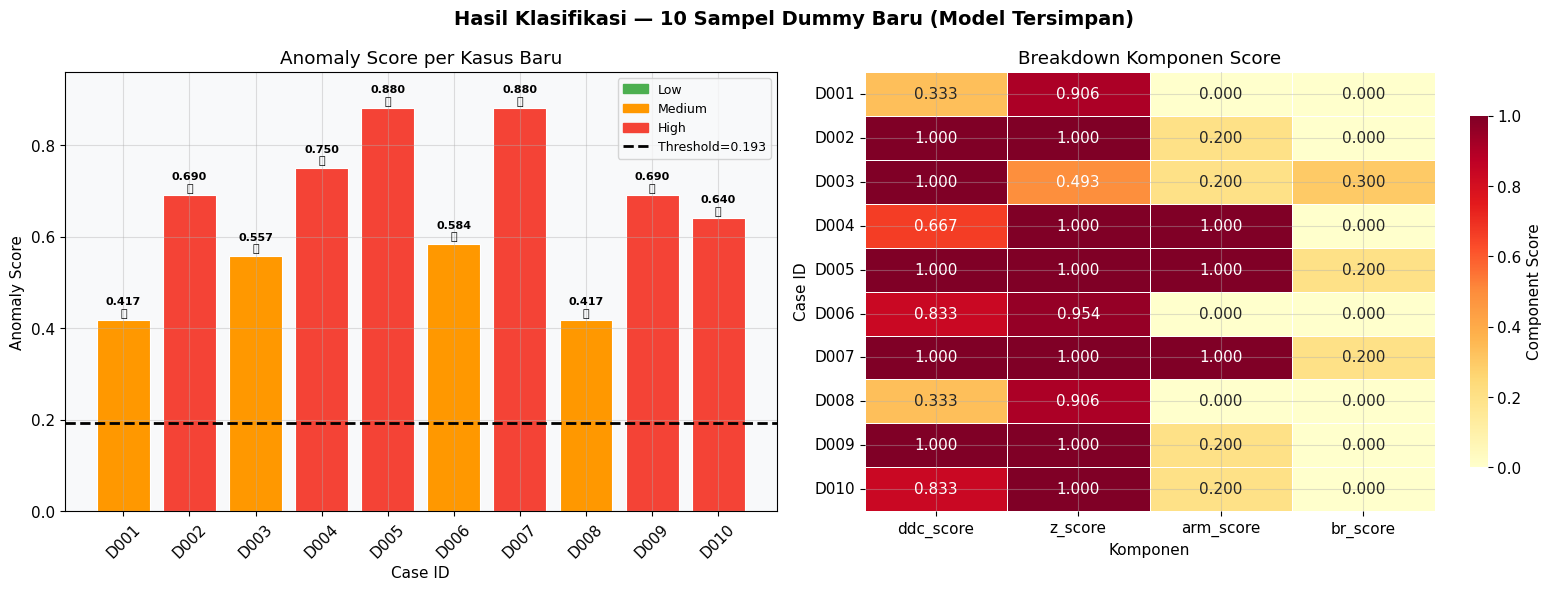

✅ Plot disimpan ke: /Users/mac/Documents/Deinony/Project/Aritificial Intelligence/DeteksiAnomaliBisnis/sendSample/dataOutput/tf_15_new_dummy_classification.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

colors_risk = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hasil Klasifikasi — 10 Sampel Dummy Baru (Model Tersimpan)',
             fontsize=14, fontweight='bold')

# (a) Bar chart anomaly score
ax = axes[0]
bar_colors = [colors_risk[r] for r in new_results['risk_level']]
bars = ax.bar(new_results['case_id'], new_results['anomaly_score'],
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(threshold_loaded, color='black', linestyle='--', lw=2,
           label=f"Threshold = {threshold_loaded:.3f}")
ax.set_title('Anomaly Score per Kasus Baru')
ax.set_xlabel('Case ID')
ax.set_ylabel('Anomaly Score')
ax.set_ylim(0, max(new_results['anomaly_score'].max() + 0.08, threshold_loaded + 0.1))
ax.tick_params(axis='x', rotation=45)

for bar, score, lbl in zip(bars, new_results['anomaly_score'], new_results['label']):
    pred = 'DEV' if score >= threshold_loaded else 'reg'
    true_short = lbl[:3]
    match_icon = '✅' if pred.lower()[:3] == true_short else '❌'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}\n{match_icon}', ha='center', va='bottom', fontsize=8, fontweight='bold')

patches = [mpatches.Patch(color=c, label=l) for l, c in colors_risk.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='black', linestyle='--', lw=2,
           label=f'Threshold={threshold_loaded:.3f}')], fontsize=9)

# (b) Heatmap score components
ax = axes[1]
score_comp = new_results[['case_id','ddc_score','z_score','arm_score','br_score']].set_index('case_id')
sns.heatmap(score_comp, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Component Score', 'shrink': 0.8})
ax.set_title('Breakdown Komponen Score')
ax.set_xlabel('Komponen')
ax.set_ylabel('Case ID')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
out_path = Path('dataOutput') / 'tf_15_new_dummy_classification.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Plot disimpan ke: {out_path.resolve()}")